**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# Linear Economy Estimation (`cultivars` edition)

This notebook re-implements the linear macroeconomic environment of Hinterlang & Tänzer (2021) -- a
recursive SVAR(2) in the output gap, inflation and the policy rate -- on top of the
[`cultivars`](https://nikhilxsunder.github.io/cultivars/) prerelease, with data from FRED via
[`fedfred`](https://nikhilxsunder.github.io/fedfred/). Relative to the original `statsmodels` / PyMC
version, the reduced form, the recursive identification, the re-estimation backtests and the
time-varying-parameter model are all `cultivars` objects; the paper's post-estimation lag restriction,
which no VAR estimator can express, is a short explicit refit on top of them.

| Section | Original | This notebook |
|---|---|---|
| Baseline recursive SVAR(2) | equation-by-equation `sm.OLS`, then restricted refit | `VAR(order=2)` + `RecursiveSVAR`, cross-checked against equation-by-equation OLS, then the same restricted refit |
| Residual diagnostics | Durbin–Watson, Breusch–Godfrey LM(1) | DW and LM(1) on the restricted equations (Table 9), plus `VARResult.residual_diagnostics()` for the system (portmanteau, Jarque–Bera, ARCH-LM) |
| Impulse responses | -- | `SVARResult.irf()` / `fevd()` under the declared ordering |
| Rolling / expanding re-estimation | hand-rolled `sm.OLS` loops | `VAR` per window, plus `Backtest`, `ForecastComparison`, `model_confidence_set`, `mincer_zarnowitz` |
| TVP-SV | PyMC ADVI-then-NUTS, one univariate equation at a time | `TVPVARSV` (Primiceri 2005 Gibbs sampler, joint system) with `TimeVaryingSVAR` for date-specific transmission |

## Reproducibility and runtime

All computations are executed in a Python virtual environment targeting **Python 3.13** (`cultivars`
requires 3.12 or later). Results may differ across Python or package versions due to numerical and
API-level changes, and the `cultivars` prerelease API may still move; pin the versions printed below and
record the full dependency set (`pip freeze`) alongside the notebook outputs.

The Gibbs sampler in the final section is the only expensive step: two independent chains of 3,000
draws each take a few minutes on a laptop. Every other cell runs in seconds.

## Software and libraries

- **Python** (>= 3.12)
- **pandas** — data wrangling and time-series preparation
- **numpy** — numerical computing
- **scipy** — reference distributions for the equation-level tests (`scipy.stats`)
- **matplotlib** — figures and visualization
- **fedfred** — programmatic access to FRED data
- **cultivars** — reduced-form VAR estimation, recursive identification, forecast backtesting and
  comparison, and the TVP-VAR-SV Gibbs sampler
- **Jupyter / IPython** — interactive execution and display utilities (`IPython.display`)

The equation-level restricted refit, Durbin–Watson and Breusch–Godfrey statistics that Table 9 reports
are computed directly with numpy and scipy, so that the table remains a like-for-like replication of the
Bundesbank baseline.

In [1]:
%pip install --pre --quiet cultivars fedfred pandas numpy scipy matplotlib
%pip install --quiet fedfred pandas numpy scipy matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

from dataclasses import dataclass
import importlib.metadata as md
from pathlib import Path
from typing import Any

from cultivars.multivariate import VAR, RecursiveSVAR, TVPVARSV, TimeVaryingSVAR
from cultivars.forecast import Backtest, ForecastComparison, model_confidence_set, mincer_zarnowitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import fedfred as fd
from IPython.display import Markdown, display


print("cultivars", md.version("cultivars"), "| fedfred", md.version("fedfred"),
      "| pandas", pd.__version__, "| numpy", np.__version__)

plt.rcParams["figure.figsize"] = (10, 4)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def show(fig: plt.Figure, name: str) -> None:
    """Save a figure to ``figures/<name>.png`` at print resolution and display it."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
    plt.show()

cultivars 1.0.0a1 | fedfred 3.0.0 | pandas 3.0.6 | numpy 2.5.3


-------------

# Baseline Specification (Bundesbank-aligned)

The baseline model estimates a **linear reduced-form macroeconomic environment** using a **recursive
(triangular) SVAR(2)** in the output gap $y_t$, inflation $\pi_t$ and the policy rate $i_t$, followed by
**post-estimation lag restriction** based on statistical significance. The resulting system is used as a
compact forecasting and simulation environment for downstream policy-learning exercises (Sims, 1980;
Lütkepohl, 2005; Hinterlang & Tänzer, 2021).

## Sample definition and modeling assumptions

### Sample window
The baseline training window is **1987Q3–2007Q2**, consistent with a pre-crisis estimation period commonly
used to limit regime breaks associated with the Global Financial Crisis. The out-of-sample window begins
in **2007Q3** and extends to the most recent available observation.

### Frequency and aggregation
All series are used at **quarterly frequency**. When a series is available at higher frequency (the
effective federal funds rate is published monthly), values are aggregated to quarters by averaging, which
is standard when mapping policy rates into quarterly policy indicators (Federal Reserve Bank of St. Louis,
n.d.).

### TVP training sample
The time-varying-parameter model in the final section calibrates its priors on a **training sample** in
the manner of Primiceri (2005): the 40 quarters before 1987Q3 (plus two for lags) are used for the prior
and then discarded, so that its estimation sample starts exactly where the baseline's does. All series
are therefore fetched from 1976Q3 and sliced afterwards.

### Linear benchmark
The estimated environment is intentionally linear and low-dimensional to serve as a tractable benchmark
for later policy-learning comparisons (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [3]:
# Training data Time Period: Q3 1987 - Q2 2007
start_date = "1987-07-01"
end_date = "2007-06-30"

# Training data Observation Frequency
freq = "q"  # Quarterly

# Fred client
fred = fd.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da", cache_mode=True, cache_size=256)

## Data utilities

### Standardizing FRED response frames
`fedfred` returns series observations in a consistent **tabular response format** (a `pandas.DataFrame`
indexed by `date` with a `value` column). To ensure uniform downstream handling (merging, lag
construction, and design-matrix formation), each response is converted into a **float-valued
`pandas.Series` with a `DatetimeIndex`** using `fedfred`'s built-in helper `FredHelpers.to_pd_series`.
This removes custom parsing logic and reduces the risk of silent type/index inconsistencies (pandas
development team, 2025; Sunder, 2025).

Each series is fetched **once over the full span** (1976Q3 to the latest observation) and sliced into the
training, out-of-sample and TVP-training windows afterwards, so that every section of the notebook works
from the same vintage of data.

## Data retrieval and construction of observables

### Data source
All time series are downloaded from the **Federal Reserve Economic Data (FRED)** database (Federal
Reserve Bank of St. Louis, n.d.). Series are retrieved at quarterly frequency with transformations
applied at the API level where appropriate to reduce downstream transformation ambiguity.

### Observables
We construct three core observables:
- **Inflation ($\pi_t$)**: year-over-year percent change in the GDP implicit price deflator (FRED series: `GDPDEF`).
- **Output gap ($y_t$)**: percent deviation of real output from potential output, computed from real GDP and CBO potential GDP (FRED series: `GDPC1`, `GDPPOT`).
- **Policy rate ($i_t$)**: quarterly average of the effective federal funds rate (FRED series: `FEDFUNDS`).

These choices mirror standard applied macro benchmarks and align with the baseline specification used
for environment estimation (Hinterlang & Tänzer, 2021; Lütkepohl, 2005).

In [4]:
# Fetch data from FRED
gdpdef_yoy = fred.get_series_observations(
    series_id="GDPDEF",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="pc1" # YoY percent change
)

real_gdp = fred.get_series_observations(
    series_id="GDPC1",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

potential_gdp = fred.get_series_observations(
    series_id="GDPPOT",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    units="lin" # Linear units (level)
)

effective_ffr = fred.get_series_observations(
    series_id="FEDFUNDS",
    observation_start=start_date,
    observation_end=end_date,
    frequency=freq,
    aggregation_method="avg" # Aggregate daily data to quarterly by averaging (specificly important for interest rates)
)

# Check data
print(gdpdef_yoy.head())
print(real_gdp.head())
print(potential_gdp.head())
print(effective_ffr.head())

           realtime_start realtime_end    value
date                                           
1987-07-01     2026-09-30   2026-09-30  2.66122
1987-10-01     2026-09-30   2026-09-30  2.91876
1988-01-01     2026-09-30   2026-09-30  3.06577
1988-04-01     2026-09-30   2026-09-30  3.35274
1988-07-01     2026-09-30   2026-09-30  3.80207
           realtime_start realtime_end     value
date                                            
1987-07-01     2026-09-30   2026-09-30  9162.024
1987-10-01     2026-09-30   2026-09-30  9319.332
1988-01-01     2026-09-30   2026-09-30  9367.502
1988-04-01     2026-09-30   2026-09-30  9490.594
1988-07-01     2026-09-30   2026-09-30  9546.206
           realtime_start realtime_end        value
date                                               
1987-07-01     2026-09-22   2026-09-22  9191.505940
1987-10-01     2026-09-22   2026-09-22  9262.554077
1988-01-01     2026-09-22   2026-09-22  9332.898162
1988-04-01     2026-09-22   2026-09-22  9402.936119
1988-07-0

### Series construction (library-standardized)
Each downloaded FRED response is converted to a `pandas.Series` using `fed.FredHelpers.to_pd_series`,
then renamed to match the model notation. This keeps the pipeline consistent across series and avoids
ad-hoc DataFrame parsing.

In [5]:
# Convert to Series with proper names
pi = fd.FredHelpers.to_pd_series(gdpdef_yoy, "pi")
y_real = fd.FredHelpers.to_pd_series(real_gdp, "y_real")
y_pot = fd.FredHelpers.to_pd_series(potential_gdp, "y_pot")
i = fd.FredHelpers.to_pd_series(effective_ffr, "i")

# Check converted data
print(pi.head())
print(y_real.head())
print(y_pot.head())
print(i.head())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
1987-07-01    9162.024
1987-10-01    9319.332
1988-01-01    9367.502
1988-04-01    9490.594
1988-07-01    9546.206
Name: y_real, dtype: float64
date
1987-07-01    9191.505940
1987-10-01    9262.554077
1988-01-01    9332.898162
1988-04-01    9402.936119
1988-07-01    9472.372905
Name: y_pot, dtype: float64
date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64


### Inflation definition and transformation
Inflation is measured as **year-over-year percent change**:

$$
\pi_t = 100 \times \left(\frac{P_t}{P_{t-4}} - 1\right).
$$

The notebook requests this transformation directly from FRED (via units corresponding to YoY percent
change), which reduces implementation variance and makes the transformation explicit at the data-source
layer (Federal Reserve Bank of St. Louis, n.d.).

In [6]:
# Double check var assignment over the training window
print(pi.head())
print(pi.tail())

date
1987-07-01    2.66122
1987-10-01    2.91876
1988-01-01    3.06577
1988-04-01    3.35274
1988-07-01    3.80207
Name: pi, dtype: float64
date
2006-04-01    3.35642
2006-07-01    3.13805
2006-10-01    2.66316
2007-01-01    2.91019
2007-04-01    2.72883
Name: pi, dtype: float64


### Output gap construction
The output gap is defined as the percent deviation of real output from potential output:

$$
y_t = 100 \times \left(\frac{Y_t}{Y_t^\ast} - 1\right).
$$

This ratio-based measure is scale-free and directly interpretable in percentage points, which is
convenient for both regression interpretation and policy simulation (Lütkepohl, 2005).

In [7]:
y_gap = 100.0 * (y_real / y_pot - 1.0)
y_gap.name = "y"

# Check calculated series
print(y_gap.head())
print(y_gap.tail())

date
1987-07-01   -0.320752
1987-10-01    0.612983
1988-01-01    0.370773
1988-04-01    0.932239
1988-07-01    0.779457
Name: y, dtype: float64
date
2006-04-01    1.316103
2006-07-01    0.921755
2006-10-01    1.268135
2007-01-01    1.053059
2007-04-01    1.151432
Name: y, dtype: float64


### Policy indicator
The policy rate $i_t$ is measured using the **effective federal funds rate**, aggregated from monthly to
quarterly frequency by averaging within each quarter to align timing with the quarterly macro series
(Federal Reserve Bank of St. Louis, n.d.).

In [8]:
# Double check var assignment
print(i.head())
print(i.tail())

date
1987-07-01    6.84
1987-10-01    6.92
1988-01-01    6.66
1988-04-01    7.16
1988-07-01    7.98
Name: i, dtype: float64
date
2006-04-01    4.91
2006-07-01    5.25
2006-10-01    5.25
2007-01-01    5.26
2007-04-01    5.25
Name: i, dtype: float64


### Alignment and integrity checks
The observables are merged into a single quarterly dataset and checked for:
- consistent quarterly indexing,
- expected sample bounds,
- absence of missing values after alignment.

These checks help ensure that subsequent lag construction and estimation are not contaminated by silent
misalignment (pandas development team, 2025). The column order `y, pi, i` is the **recursive ordering**
that every `cultivars` identification below declares.

In [9]:
# Merge
df = pd.concat([pi, y_gap, i], axis=1).dropna()
df.index = pd.PeriodIndex(df.index, freq="Q") # Use a quarterly PeriodIndex

# Check
print(df.head())
print(df.tail())
print(df.index.min(), "→", df.index.max())

# Additional Sanity Check:
assert df.index.min() == pd.Period("1987Q3", "Q")
assert df.index.max() == pd.Period("2007Q2", "Q")
assert len(df) == 80
assert not df.isna().any().any()

             pi         y     i
date                           
1987Q3  2.66122 -0.320752  6.84
1987Q4  2.91876  0.612983  6.92
1988Q1  3.06577  0.370773  6.66
1988Q2  3.35274  0.932239  7.16
1988Q3  3.80207  0.779457  7.98
             pi         y     i
date                           
2006Q2  3.35642  1.316103  4.91
2006Q3  3.13805  0.921755  5.25
2006Q4  2.66316  1.268135  5.25
2007Q1  2.91019  1.053059  5.26
2007Q2  2.72883  1.151432  5.25
1987Q3 → 2007Q2


## Estimating the linear environment (restricted recursive SVAR(2))

We estimate a **recursive reduced-form SVAR(2)**. The recursive structure is implemented by allowing
inflation to depend contemporaneously on the output gap (triangular ordering), which corresponds to a
standard Cholesky-style identification in VAR applications (Sims, 1980; Lütkepohl, 2005).

The paper writes the system in **structural form**, with contemporaneous $y_t$ in the inflation equation:

$$
y_t = C^y + a^{y\prime} s_t + \varepsilon^y_t,\qquad
\pi_t = C^\pi + a^\pi_{y,0}\,y_t + a^{\pi\prime} s_t + \varepsilon^\pi_t,\qquad
s_t = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

`cultivars` estimates the **reduced form** with `VAR` and identifies the recursive structure with
`RecursiveSVAR`; the two representations are linked exactly by the Cholesky factor $B$ of the residual
covariance:

$$
a^\pi_{y,0} = B_{\pi y} / B_{yy},\qquad
a^\pi_{\cdot} = \tilde a^\pi_{\cdot} - a^\pi_{y,0}\,\tilde a^y_{\cdot},
$$

where $\tilde a$ are reduced-form coefficients. The output-gap equation is identical in both forms because
$y$ is ordered first. Estimating the reduced form by multivariate least squares and applying the
triangular factor is numerically identical to the paper's equation-by-equation OLS on the structural
form; the notebook verifies that identity below before applying the lag restriction.

### Lag order
The paper fixes the lag order at $p = 2$. `cultivars` reports the information-criterion sweep on the
training sample as a check that this choice is defensible rather than assumed.

In [ ]:
lag_selection = VAR(df_train[NAMES].to_numpy(), order=2, trend="c", names=NAMES).lag_order_selection(max_lags=6)
print(lag_selection.to_table())

                              Lag order selection
Observations:                       74  Maximum lags:                        6
Consensus:                           2
--------------------------------------------------------------------------------
p          AIC        BIC       HQIC       FPE
0       0.9618     1.0552     0.9990    2.6163
1      -6.8696    -6.4959    -6.7205    0.0010
2     -7.2675*   -6.6137*   -7.0067*   0.0007*
3      -7.1255    -6.1914    -6.7529    0.0008
4      -6.9649    -5.7506    -6.4805    0.0010
5      -7.0662    -5.5717    -6.4700    0.0009
6      -6.9801    -5.2053    -6.2721    0.0010
An asterisk marks each criterion's minimum. Every order was scored on the same
sample, so entries within a column are comparable; FPE is on a determinant
scale, so entries across columns are not.


### Reduced-form VAR(2) and recursive identification
The reduced form is estimated on the training window and the recursive ordering $y \to \pi \to i$ is
declared explicitly through `RecursiveSVAR`. The `cultivars` summaries report the reduced-form
coefficients with standard errors and p-values, the stability of the companion matrix, and the impact
matrix implied by the ordering.

In [ ]:
# Reduced-form VAR(2) on the training window, recursive identification y -> pi -> i
var = VAR(df_train[NAMES].to_numpy(), order=2, trend="c", names=NAMES).fit()
svar = RecursiveSVAR(var, order=NAMES).identify()

print(var.summary())
print(svar.summary())

stability = var.stability_check()
print("Stable:", var.is_stable, "| max |companion root| =", round(float(stability.max_modulus), 4),
      "| effective observations:", var.nobs)

                                 VAR(2) Results
Model:                          VAR(2)  Log-likelihood:                -32.300
Variables:                           3  AIC:                           118.600
Trend:                               c  BIC:                           182.231
Observations:                       78  HQIC:                          144.073
--------------------------------------------------------------------------------
                 coef   std err        z   P>|z|    [0.025    0.975]
y: const       0.2609    0.1911    1.365   0.172   -0.1136    0.6353
y: y.L1        1.0054    0.1275    7.887   0.000    0.7556    1.2553
y: pi.L1      -0.1594    0.3012   -0.529   0.597   -0.7498    0.4311
y: i.L1        0.2084    0.1628    1.280   0.201   -0.1107    0.5274
y: y.L2       -0.0955    0.1260   -0.758   0.448   -0.3425    0.1515
y: pi.L2       0.1105    0.3041    0.363   0.716   -0.4856    0.7066
y: i.L2       -0.2320    0.1518   -1.529   0.126   -0.5295    0.0655
pi:

### Estimation outputs
For transparency and reproducibility, the equation-level estimation routine returns:
- fitted OLS objects (full and restricted) for each structural equation,
- the design matrices used for prediction,
- residual series for diagnostics,
- coefficient and p-value tables that remain index-stable even after restrictions.

This design supports clean table construction and avoids downstream errors when terms are excluded
during restriction. The helpers below are deliberately small: the restricted refit is ordinary least
squares with named columns dropped, and the Durbin–Watson and Breusch–Godfrey statistics follow the
`statsmodels` conventions used in the original notebook (Seabold & Perktold, 2010).

In [ ]:
@dataclass(frozen=True)
class EquationFit:
    """OLS fit of one structural equation on a named design matrix.

    Attributes:
        name: Dependent variable label (``"y"`` or ``"pi"``).
        params: Coefficient estimates, indexed by regressor name.
        bse: Conventional (non-robust) standard errors.
        tvalues: t statistics.
        pvalues: Two-sided p-values under the t distribution with ``df_resid`` degrees of freedom.
        resid: Residuals over the estimation sample.
        fittedvalues: Fitted values over the estimation sample.
        design: The design matrix as estimated (constant included).
        nobs: Number of observations.
        df_resid: Residual degrees of freedom ``nobs - k``.
        ssr: Sum of squared residuals.
        rsquared: Coefficient of determination.
        rsquared_adj: Adjusted coefficient of determination.
    """

    name: str
    params: pd.Series
    bse: pd.Series
    tvalues: pd.Series
    pvalues: pd.Series
    resid: pd.Series
    fittedvalues: pd.Series
    design: pd.DataFrame
    nobs: int
    df_resid: int
    ssr: float
    rsquared: float
    rsquared_adj: float

    @property
    def mse_resid(self) -> float:
        """Residual variance estimate ``SSR / (n - k)`` (statsmodels' ``mse_resid``)."""
        return self.ssr / self.df_resid

    def predict(self, X: pd.DataFrame) -> pd.Series:
        """Linear prediction on a design matrix that contains (at least) this fit's regressors."""
        missing = [c for c in self.params.index if c not in X.columns]
        if missing:
            raise KeyError(f"design matrix lacks regressors {missing}")
        values = X[list(self.params.index)].to_numpy(dtype=float) @ self.params.to_numpy(dtype=float)
        return pd.Series(values, index=X.index, name=f"{self.name}_hat")

    def summary_frame(self) -> pd.DataFrame:
        """Coefficient table in the familiar ``coef / std err / t / P>|t|`` layout."""
        return pd.DataFrame({"coef": self.params, "std err": self.bse, "t": self.tvalues, "P>|t|": self.pvalues})


def ols(y: pd.Series, X: pd.DataFrame, *, name: str) -> EquationFit:
    """Ordinary least squares with conventional standard errors.

    Args:
        y: Dependent variable.
        X: Design matrix with a ``const`` column already present; must share ``y``'s index.
        name: Label for the dependent variable.

    Returns:
        The :class:`EquationFit`.

    Raises:
        ValueError: If the indices disagree, values are missing, or there are too few observations.
    """
    if not y.index.equals(X.index):
        raise ValueError("y and X must share the same index")
    if X.isna().any().any() or y.isna().any():
        raise ValueError("y and X must not contain missing values")
    Xv = X.to_numpy(dtype=float)
    yv = y.to_numpy(dtype=float)
    n, k = Xv.shape
    if n <= k:
        raise ValueError(f"need more observations ({n}) than regressors ({k})")

    beta, *_ = np.linalg.lstsq(Xv, yv, rcond=None)
    fitted = Xv @ beta
    resid = yv - fitted
    ssr = float(resid @ resid)
    df_resid = n - k
    sigma2 = ssr / df_resid
    cov = sigma2 * np.linalg.inv(Xv.T @ Xv)
    bse = np.sqrt(np.diag(cov))
    tvalues = beta / bse
    pvalues = 2.0 * stats.t.sf(np.abs(tvalues), df_resid)
    tss = float(((yv - yv.mean()) ** 2).sum())
    r2 = 1.0 - ssr / tss
    r2_adj = 1.0 - (1.0 - r2) * (n - 1) / df_resid

    cols = list(X.columns)
    return EquationFit(
        name=name,
        params=pd.Series(beta, index=cols, name="coef"),
        bse=pd.Series(bse, index=cols, name="std err"),
        tvalues=pd.Series(tvalues, index=cols, name="t"),
        pvalues=pd.Series(pvalues, index=cols, name="P>|t|"),
        resid=pd.Series(resid, index=X.index, name=f"eps_{name}"),
        fittedvalues=pd.Series(fitted, index=X.index, name=f"{name}_fit"),
        design=X.copy(),
        nobs=n,
        df_resid=df_resid,
        ssr=ssr,
        rsquared=r2,
        rsquared_adj=r2_adj,
    )


def durbin_watson(resid: pd.Series) -> float:
    """Durbin–Watson statistic ``sum (e_t - e_{t-1})^2 / sum e_t^2``."""
    e = np.asarray(resid, dtype=float)
    return float(np.sum(np.diff(e) ** 2) / np.sum(e**2))


def breusch_godfrey_lm(fit: EquationFit, nlags: int = 1) -> tuple[float, float]:
    """Breusch–Godfrey LM test for residual serial correlation up to ``nlags``.

    Follows the ``statsmodels.acorr_breusch_godfrey`` convention: lagged residuals are padded with
    zeros, the auxiliary regression uses the original regressors plus the lagged residuals, and
    ``LM = n R^2`` is referred to a chi-squared distribution with ``nlags`` degrees of freedom.

    Returns:
        ``(statistic, p-value)``.
    """
    e = fit.resid.to_numpy(dtype=float)
    n = e.size
    lagged = np.column_stack([np.concatenate([np.zeros(lag), e[:-lag]]) for lag in range(1, nlags + 1)])
    Z = np.column_stack([fit.design.to_numpy(dtype=float), lagged])
    gamma, *_ = np.linalg.lstsq(Z, e, rcond=None)
    u = e - Z @ gamma
    r2 = 1.0 - float(u @ u) / float((e - e.mean()) @ (e - e.mean()))
    lm = n * r2
    return float(lm), float(stats.chi2.sf(lm, nlags))


Y_REGRESSORS = ["y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]
PI_REGRESSORS = ["y", "y_lag1", "y_lag2", "pi_lag1", "pi_lag2", "i_lag1", "i_lag2"]


def structural_design(df: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame, pd.Series, pd.DataFrame]:
    """Targets and design matrices of the two structural equations on a common index.

    The first two rows are dropped so that both equations share the same effective sample, which is
    also the sample the `cultivars` ``VAR`` uses.

    Returns:
        ``(y_target, X_y, pi_target, X_pi)``; both design matrices carry a leading ``const`` column.
    """
    work = df[NAMES].copy().sort_index()
    for c in NAMES:
        work[f"{c}_lag1"] = work[c].shift(1)
        work[f"{c}_lag2"] = work[c].shift(2)
    work = work.dropna()
    X_y = work[Y_REGRESSORS].copy()
    X_y.insert(0, "const", 1.0)
    X_pi = work[PI_REGRESSORS].copy()
    X_pi.insert(0, "const", 1.0)
    return work["y"], X_y, work["pi"], X_pi

### Structural form from the reduced form (cross-check)
The helper below converts the `cultivars` reduced-form estimates and the Cholesky impact matrix into the
paper's structural notation. The result is compared with equation-by-equation OLS on the structural
design matrices: the two must agree to machine precision, which confirms that the `cultivars`
identification reproduces the paper's estimator exactly on the unrestricted system.

In [ ]:
# cultivars regressor labels -> notebook labels
REG_MAP = {"const": "const", "y": "y",
           "y.L1": "y_lag1", "y.L2": "y_lag2",
           "pi.L1": "pi_lag1", "pi.L2": "pi_lag2",
           "i.L1": "i_lag1", "i.L2": "i_lag2"}


def structural_equations(var, svar) -> dict[str, dict[str, float]]:
    """Recursive structural-form coefficients (paper notation) from a fitted VAR and its Cholesky factor."""
    B = svar.impact                                   # lower-triangular impact matrix, order y -> pi -> i
    red_y, red_pi = var.equation("y"), var.equation("pi")
    a_y0 = float(B[1, 0] / B[0, 0])                   # contemporaneous y in the pi equation
    struct_pi = {"const": red_pi["const"] - a_y0 * red_y["const"], "y": a_y0}
    struct_pi.update({k: red_pi[k] - a_y0 * red_y[k] for k in red_pi if k != "const"})
    return {"y": {REG_MAP[k]: v for k, v in red_y.items()},
            "pi": {REG_MAP[k]: v for k, v in struct_pi.items()}}


# Unrestricted structural equations, two ways
y_target, X_y_full, pi_target, X_pi_full = structural_design(df_train)
full_y = ols(y_target, X_y_full, name="y")
full_pi = ols(pi_target, X_pi_full, name="pi")
struct = structural_equations(var, svar)

ols_params = pd.concat([full_y.params.add_prefix("y: "), full_pi.params.add_prefix("pi: ")])
cult_params = pd.concat([pd.Series(struct["y"]).add_prefix("y: "),
                         pd.Series(struct["pi"]).add_prefix("pi: ")]).reindex(ols_params.index)
check = pd.DataFrame({"cultivars (VAR + Cholesky)": cult_params,
                      "equation-by-equation OLS": ols_params}, index=ols_params.index)
check["abs diff"] = (check.iloc[:, 0] - check.iloc[:, 1]).abs()
assert np.allclose(check.iloc[:, 0], check.iloc[:, 1], atol=1e-8), "structural mapping and OLS disagree"
display(check.round(6))
print("Effective sample (cultivars, OLS):", var.nobs, full_y.nobs)

,cultivars (VAR + Cholesky),equation-by-equation OLS,abs diff
y: const,0.260856,0.260856,0.0
y: y_lag1,1.005421,1.005421,0.0
y: y_lag2,-0.095527,-0.095527,0.0
y: pi_lag1,-0.159359,-0.159359,0.0
y: pi_lag2,0.110534,0.110534,0.0
y: i_lag1,0.208374,0.208374,0.0
y: i_lag2,-0.232032,-0.232032,0.0
pi: const,0.135292,0.135292,0.0
pi: y,-0.073871,-0.073871,0.0
pi: y_lag1,0.190689,0.190689,0.0


Effective sample (cultivars, OLS): 78 78


### Restriction rule (post-estimation lag selection)
Following the baseline approach, the SVAR(2) is first estimated in full and then **restricted by
removing statistically weak second-lag terms** using a significance threshold (default $\alpha = 0.10$)
applied to the full-model p-values of each structural equation. This yields a more parsimonious linear
environment while retaining the SVAR(2) starting point as the reference specification (Hinterlang &
Tänzer, 2021). No VAR estimator can express equation-specific zero restrictions, so the refit is an
explicit OLS step on the structural design matrices.

In [ ]:
ALPHA_DROP = 0.10


def identify_insignificant_lag2_terms(fit: EquationFit, *, alpha: float = ALPHA_DROP,
                                      suffix: str = "_lag2") -> list[str]:
    """Return the lag-2 regressor names of ``fit`` whose p-value exceeds ``alpha``."""
    return [k for k in fit.params.index if k.endswith(suffix) and float(fit.pvalues[k]) > alpha]


for label, fit in (("y", full_y), ("pi", full_pi)):
    print(f"{label} equation: lag-2 terms with p > {ALPHA_DROP}:", identify_insignificant_lag2_terms(fit) or "none")

y equation: lag-2 terms with p > 0.1: ['y_lag2', 'pi_lag2', 'i_lag2']
pi equation: lag-2 terms with p > 0.1: ['i_lag2']


### Estimation procedure

Let the state vector contain the output gap $y_t$, inflation $\pi_t$, and policy rate $i_t$. The linear
environment is estimated as a pair of reduced-form equations with up to two lags.

1. **Output-gap equation (no contemporaneous regressors)**
$$
y_t = C^y + \alpha^{y\prime} s_t^y + \varepsilon_t^y, \quad
s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

2. **Inflation equation (recursive ordering allows contemporaneous $y_t$)**
$$
\pi_t = C^\pi + \alpha^{\pi\prime} s_t^\pi + \varepsilon_t^\pi, \quad
s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

Both equations are first estimated via OLS (numerically identical to the `cultivars` reduced form plus
Cholesky identification, as verified above), and the model is then **restricted** by dropping
insignificant second-lag regressors based on the full-model p-values. This is a pragmatic, transparent
approach to obtain a compact environment suitable for simulation and comparison (Sims, 1980; Hinterlang
& Tänzer, 2021; Lütkepohl, 2005).

In [ ]:
@dataclass(frozen=True)
class SVARFit:
    """Full and restricted equation-by-equation fits of the recursive SVAR(2).

    Attributes:
        full_y: Unrestricted output-gap equation.
        full_pi: Unrestricted (structural) inflation equation.
        mod_y: Restricted output-gap refit.
        mod_pi: Restricted inflation refit.
        zeroed_y: Regressors dropped from the output-gap equation.
        zeroed_pi: Regressors dropped from the inflation equation.
    """

    full_y: EquationFit
    full_pi: EquationFit
    mod_y: EquationFit
    mod_pi: EquationFit
    zeroed_y: tuple[str, ...]
    zeroed_pi: tuple[str, ...]

    def coef(self, equation: str) -> pd.Series:
        """Table-safe restricted coefficients: dropped terms appear with value ``0.0``."""
        full, mod = (self.full_y, self.mod_y) if equation == "y" else (self.full_pi, self.mod_pi)
        return mod.params.reindex(full.params.index, fill_value=0.0)

    def pvalues(self, equation: str) -> pd.Series:
        """Table-safe p-values: dropped terms carry the full-model p-value that justified the drop."""
        full, mod = (self.full_y, self.mod_y) if equation == "y" else (self.full_pi, self.mod_pi)
        return mod.pvalues.reindex(full.params.index).fillna(full.pvalues)


def fit_linear_svar(df: pd.DataFrame, *, alpha_drop: float = ALPHA_DROP) -> SVARFit:
    """Paper-aligned procedure.

    1. Fit the full SVAR(2) equation by equation (OLS).
    2. Drop insignificant ``*_lag2`` terms (p > ``alpha_drop``) based on the full fit.
    3. Refit the restricted equations without those regressors.
    """
    y_t, X_y, pi_t, X_pi = structural_design(df)

    full_y = ols(y_t, X_y, name="y")
    drop_y = identify_insignificant_lag2_terms(full_y, alpha=alpha_drop)
    mod_y = ols(y_t, X_y.drop(columns=drop_y), name="y")

    full_pi = ols(pi_t, X_pi, name="pi")
    drop_pi = identify_insignificant_lag2_terms(full_pi, alpha=alpha_drop)
    mod_pi = ols(pi_t, X_pi.drop(columns=drop_pi), name="pi")

    return SVARFit(full_y=full_y, full_pi=full_pi, mod_y=mod_y, mod_pi=mod_pi,
                   zeroed_y=tuple(drop_y), zeroed_pi=tuple(drop_pi))

In [ ]:
# Fit the restricted recursive SVAR(2)
svar_fit = fit_linear_svar(df_train, alpha_drop=ALPHA_DROP)

for label, fit in (("Output gap equation (restricted)", svar_fit.mod_y),
                   ("Inflation equation (restricted)", svar_fit.mod_pi)):
    lm, lm_p = breusch_godfrey_lm(fit, 1)
    print(f"\n=== {label} ===")
    print(f"nobs = {fit.nobs} | R2 = {fit.rsquared:.4f} | adj R2 = {fit.rsquared_adj:.4f} | "
          f"sigma = {np.sqrt(fit.mse_resid):.4f} | DW = {durbin_watson(fit.resid):.4f} | "
          f"LM(1) = {lm:.4f} (p = {lm_p:.4f})")
    print(fit.summary_frame().round(4).to_string())

# Sanity checks
print("\nResidual std (y, pi):", svar_fit.mod_y.resid.std().round(3), svar_fit.mod_pi.resid.std().round(3))
print("Samples used (y, pi):", svar_fit.mod_y.nobs, svar_fit.mod_pi.nobs)


=== Output gap equation (restricted) ===
nobs = 78 | R2 = 0.8643 | adj R2 = 0.8588 | sigma = 0.4814 | DW = 1.7254 | LM(1) = 1.7255 (p = 0.1890)
           coef  std err        t   P>|t|
const    0.3070   0.1849   1.6602  0.1011
y_lag1   0.9775   0.0535  18.2819  0.0000
pi_lag1 -0.0228   0.0810  -0.2821  0.7787
i_lag1  -0.0499   0.0359  -1.3907  0.1685

=== Inflation equation (restricted) ===
nobs = 78 | R2 = 0.9517 | adj R2 = 0.9477 | sigma = 0.1849 | DW = 2.1003 | LM(1) = 1.6139 (p = 0.2039)
           coef  std err        t   P>|t|
const    0.1275   0.0745   1.7104  0.0916
y       -0.0642   0.0451  -1.4218  0.1595
y_lag1   0.2086   0.0658   3.1720  0.0022
y_lag2  -0.1094   0.0471  -2.3232  0.0230
pi_lag1  1.2914   0.1058  12.2100  0.0000
pi_lag2 -0.3150   0.1092  -2.8835  0.0052
i_lag1  -0.0169   0.0153  -1.1042  0.2732

Residual std (y, pi): 0.472 0.178
Samples used (y, pi): 78 78


In [ ]:
# Sanity check: table-safe coefficient and p-value views (dropped terms carry 0.0 / full-model p)
for eq in ("y", "pi"):
    print(f"--- {eq} equation ---")
    print(pd.DataFrame({"coef": svar_fit.coef(eq), "p-value": svar_fit.pvalues(eq)}).to_string())

print("Zeroed in y eq:", list(svar_fit.zeroed_y))
print("Zeroed in pi eq:", list(svar_fit.zeroed_pi))

--- y equation ---
             coef       p-value
const    0.306997  1.011005e-01
y_lag1   0.977454  3.683435e-29
y_lag2   0.000000  4.509506e-01
pi_lag1 -0.022849  7.786596e-01
pi_lag2  0.000000  7.173563e-01
i_lag1  -0.049870  1.684990e-01
i_lag2   0.000000  1.307824e-01
--- pi equation ---
             coef       p-value
const    0.127484  9.156578e-02
y       -0.064184  1.594715e-01
y_lag1   0.208635  2.236825e-03
y_lag2  -0.109355  2.303619e-02
pi_lag1  1.291417  4.114369e-19
pi_lag2 -0.314953  5.200803e-03
i_lag1  -0.016861  2.732352e-01
i_lag2   0.000000  2.395416e-01
Zeroed in y eq: ['y_lag2', 'pi_lag2', 'i_lag2']
Zeroed in pi eq: ['i_lag2']


### Restricted reduced-form representation

After applying the lag restriction rule, the environment can be written as:
- a restricted output-gap equation with a subset of lag terms retained, and
- a restricted inflation equation that may include contemporaneous $y_t$ under the recursive ordering.

This representation is interpreted as a **reduced-form forecasting system**, not a fully structural causal
model (Sims, 1980; Lütkepohl, 2005).

### Linear environment mapping
The restricted SVAR defines a mapping from observed state variables and lags to one-step-ahead fitted
values:
$$
\hat f^m(s_t^m) = C^m + \alpha^{m\prime}s_t^m,\quad m\in\{\pi,y\}.
$$
This serves as the notebook's **linear economy environment** used for in-sample diagnostics and
out-of-sample comparison (Hinterlang & Tänzer, 2021).

### Substituted System

In [ ]:
TERM_TEX = {"const": "", "y": "y_t",
            "y_lag1": "y_{t-1}", "y_lag2": "y_{t-2}",
            "pi_lag1": r"\pi_{t-1}", "pi_lag2": r"\pi_{t-2}",
            "i_lag1": "i_{t-1}", "i_lag2": "i_{t-2}"}


def equation_tex(lhs: str, coef: pd.Series) -> str:
    """Display-math string of an estimated equation; zero (dropped) terms are omitted."""
    body = f"{coef['const']:.4f}"
    for k, v in coef.items():
        if k == "const" or v == 0.0:
            continue
        body += f" {'-' if v < 0 else '+'} {abs(v):.4f}{TERM_TEX[k]}"
    return f"$${lhs} = {body}$$"


display(Markdown("The restricted equations with their coefficients are as follows:"))
display(Markdown(equation_tex("y_t", svar_fit.coef("y"))))
display(Markdown(equation_tex(r"\pi_t", svar_fit.coef("pi"))))

The restricted equations with their coefficients are as follows:

$$y_t = 0.3070 + 0.9775y_{t-1} - 0.0228\pi_{t-1} - 0.0499i_{t-1}$$

$$\pi_t = 0.1275 - 0.0642y_t + 0.2086y_{t-1} - 0.1094y_{t-2} + 1.2914\pi_{t-1} - 0.3150\pi_{t-2} - 0.0169i_{t-1}$$

### Table 9 — Restricted SVAR estimates and diagnostics (replication-style summary)

The table reports restricted OLS coefficients and associated p-values, together with standard residual
diagnostics (adjusted $\bar R^2$, MSE, the residual variance estimate, Durbin–Watson, and the
Breusch–Godfrey LM(1) statistic with its $\chi^2(1)$ p-value). These statistics provide a compact
assessment of fit and residual dependence for the linear benchmark (Seabold & Perktold, 2010). The
system-level residual diagnostics that `cultivars` reports for the unrestricted VAR follow in the next
subsection.

In [ ]:
PARAM_TEX = {
    "y": {"const": r"$C^y$", "y_lag1": r"$a^y_{y,1}$", "y_lag2": r"$a^y_{y,2}$",
          "pi_lag1": r"$a^y_{\pi,1}$", "pi_lag2": r"$a^y_{\pi,2}$",
          "i_lag1": r"$a^y_{i,1}$", "i_lag2": r"$a^y_{i,2}$"},
    "pi": {"const": r"$C^\pi$", "y": r"$a^\pi_{y,0}$", "y_lag1": r"$a^\pi_{y,1}$", "y_lag2": r"$a^\pi_{y,2}$",
           "pi_lag1": r"$a^\pi_{\pi,1}$", "pi_lag2": r"$a^\pi_{\pi,2}$",
           "i_lag1": r"$a^\pi_{i,1}$", "i_lag2": r"$a^\pi_{i,2}$"},
}
TABLE_NINE_FOOTNOTE = ("* sigma-hat^2 is the residual variance estimate SSR/(n - k); MSE is SSR/n; "
                       "LM(1) is the Breusch-Godfrey statistic with its chi-squared(1) p-value.")


def table_nine_markdown(fit: SVARFit) -> str:
    """Markdown source of Table 9 (restricted estimates, p-values, and residual diagnostics)."""
    lines = ["| Parameters | Local OLS Estimate | p-Value |", "|------------|--------------------|---------|"]
    blocks = (("y", "Output gap equation", r"$\hat\sigma_{\varepsilon_1}^2$", fit.mod_y),
              ("pi", "Inflation equation", r"$\hat\sigma_{\varepsilon_2}^2$", fit.mod_pi))
    for eq, label, sigma_tex, m in blocks:
        lines.append(f"| **{label}** |  |  |")
        for k in fit.coef(eq).index:            # full-design order; dropped terms are skipped
            if k in m.params.index:
                lines.append(f"| {PARAM_TEX[eq][k]} | {m.params[k]:.4f} | {m.pvalues[k]:.4f} |")
        lm, lm_p = breusch_godfrey_lm(m, 1)
        lines.append(f"| $\\bar{{R}}^2$ | {m.rsquared_adj:.4f} | |")
        lines.append(f"| MSE | {m.ssr / m.nobs:.4f} | |")
        lines.append(f"| {sigma_tex} | {m.mse_resid:.4f} | |")
        lines.append(f"| DW | {durbin_watson(m.resid):.4f} | |")
        lines.append(f"| LM(1) | {lm:.4f} | {lm_p:.4f} |")
    lines.append("\\" + TABLE_NINE_FOOTNOTE)
    return "\n".join(lines)


table_nine_md = table_nine_markdown(svar_fit)
display(Markdown("**Table 9 — Restricted SVAR estimates and diagnostics**\n\n" + table_nine_md))

**Table 9 — Restricted SVAR estimates and diagnostics**

| Parameters | Local OLS Estimate | p-Value |
|------------|--------------------|---------|
| **Output gap equation** |  |  |
| $C^y$ | 0.3070 | 0.1011 |
| $a^y_{y,1}$ | 0.9775 | 0.0000 |
| $a^y_{\pi,1}$ | -0.0228 | 0.7787 |
| $a^y_{i,1}$ | -0.0499 | 0.1685 |
| $\bar{R}^2$ | 0.8588 | |
| MSE | 0.2198 | |
| $\hat\sigma_{\varepsilon_1}^2$ | 0.2317 | |
| DW | 1.7254 | |
| LM(1) | 1.7255 | 0.1890 |
| **Inflation equation** |  |  |
| $C^\pi$ | 0.1275 | 0.0916 |
| $a^\pi_{y,0}$ | -0.0642 | 0.1595 |
| $a^\pi_{y,1}$ | 0.2086 | 0.0022 |
| $a^\pi_{y,2}$ | -0.1094 | 0.0230 |
| $a^\pi_{\pi,1}$ | 1.2914 | 0.0000 |
| $a^\pi_{\pi,2}$ | -0.3150 | 0.0052 |
| $a^\pi_{i,1}$ | -0.0169 | 0.2732 |
| $\bar{R}^2$ | 0.9477 | |
| MSE | 0.0311 | |
| $\hat\sigma_{\varepsilon_2}^2$ | 0.0342 | |
| DW | 2.1003 | |
| LM(1) | 1.6139 | 0.2039 |
\* sigma-hat^2 is the residual variance estimate SSR/(n - k); MSE is SSR/n; LM(1) is the Breusch-Godfrey statistic with its chi-squared(1) p-value.

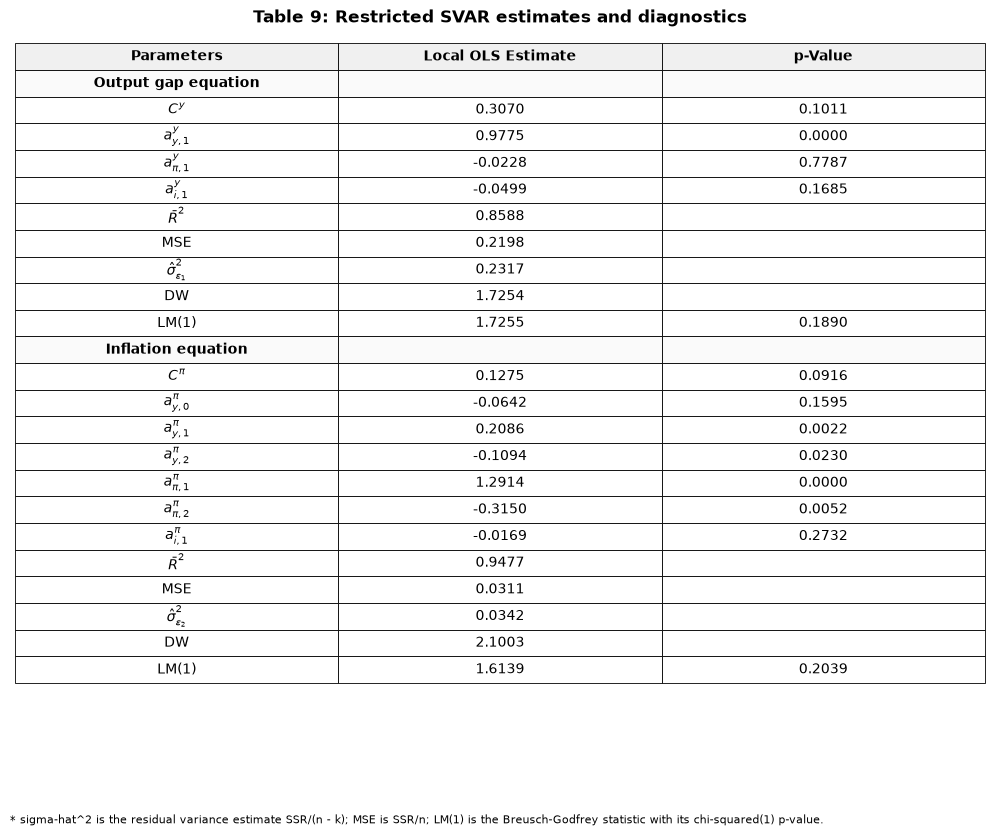

Saved: figures/table9.png


In [ ]:
def _is_md_separator_row(line: str) -> bool:
    s = line.strip()
    return s.startswith("|") and set(s.replace(" ", "")) <= set("|-:")


def _parse_md_row(line: str) -> list[str]:
    # "| a | b | c |" -> ["a", "b", "c"]
    return [c.strip() for c in line.strip().strip("|").split("|")]


def render_md_table_matplotlib(md_src: str, *, title: str, outpath: Path, dpi: int = 300):
    """Render a pipe-delimited Markdown table (with **section** rows and a footnote) as a PNG."""
    raw_rows: list[list[str]] = []
    footnote = None
    for ln in str(md_src).splitlines():
        ln = ln.strip()
        if not ln or _is_md_separator_row(ln):
            continue
        if ln.startswith("|") and ln.endswith("|"):
            raw_rows.append(_parse_md_row(ln))
        elif ln.startswith("\\*") or ln.startswith("*"):
            footnote = ln.lstrip("\\").strip()
    if len(raw_rows) < 2:
        raise ValueError("Not enough table rows found in md.")

    col_labels = raw_rows[0]
    body = raw_rows[1:]
    ncols = len(col_labels)
    body = [row + [""] * (ncols - len(row)) if len(row) < ncols else row[:ncols] for row in body]

    fig_h = max(2.0, 0.35 * (len(body) + 1))
    fig, ax = plt.subplots(figsize=(10, fig_h))
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=4)

    tbl = ax.table(cellText=body, colLabels=col_labels, cellLoc="center", colLoc="center", loc="upper center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.35)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.6)
        if r == 0:                                  # header row
            cell.set_facecolor("#f0f0f0")
            cell.set_text_props(weight="bold")

    for r, row in enumerate(body, start=1):         # body rows start at r=1
        first = row[0].strip()
        if first.startswith("**") and first.endswith("**"):
            tbl[(r, 0)].get_text().set_text(first.strip("*"))
            for c in range(ncols):
                tbl[(r, c)].set_facecolor("#fafafa")
                tbl[(r, c)].set_text_props(weight="bold")

    if footnote:
        fig.text(0.01, 0.01, footnote, ha="left", va="bottom", fontsize=8)

    fig.tight_layout(rect=[0, 0.03, 1, 1])
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig, ax, tbl


fig, ax, tbl = render_md_table_matplotlib(
    table_nine_md, title="Table 9: Restricted SVAR estimates and diagnostics", outpath=FIG_DIR / "table9.png"
)
plt.show()
print("Saved:", FIG_DIR / "table9.png")

### System residual diagnostics (`cultivars`)
Table 9 reports single-equation serial-correlation statistics, as the paper does. `cultivars` adds the
system-level view on the unrestricted VAR(2): a multivariate portmanteau test on the residual
autocorrelations, Jarque–Bera normality per equation, and an ARCH-LM test per equation. A rejected
portmanteau would indicate that two lags leave dependence in the residuals; ARCH effects would motivate
the stochastic-volatility model of the final section.

In [ ]:
print(var.residual_diagnostics(portmanteau_lags=8, arch_lags=4))
print("Residual std (y, pi, i):", np.round(np.sqrt(np.diag(var.sigma_u)), 3))

                              Residual diagnostics
Observations:                       78  Equations:                           3
--------------------------------------------------------------------------------
test                statistic   df   p-value
portmanteau(8)         57.848   51    0.2372
jarque-bera[y]          1.059    2    0.5890
jarque-bera[pi]         2.130    2    0.3447
jarque-bera[i]          1.120    2    0.5712
arch-lm(4)[y]           1.054    4    0.9015
arch-lm(4)[pi]          1.904    4    0.7534
arch-lm(4)[i]           8.643    4    0.0707
Small p-values reject the null named by each test. A rejected portmanteau means
the lag order is too short, which invalidates every other quantity the result
reports.
Residual std (y, pi, i): [0.478 0.186 0.311]


### Impulse responses of the environment
A policy-learning agent acts through $i_t$; the recursive SVAR says how the environment answers. The
grid below shows the responses of every variable to a one-standard-deviation structural shock in every
variable under the ordering $y \to \pi \to i$: the policy rate reacts to output and prices within the
quarter, while output and prices react to the rate with a lag. That is the identifying assumption, stated
as such in the `RecursiveSVAR` summary. The forecast-error variance decomposition quantifies how much of
the variation in the output gap and inflation the model attributes to policy-rate shocks.

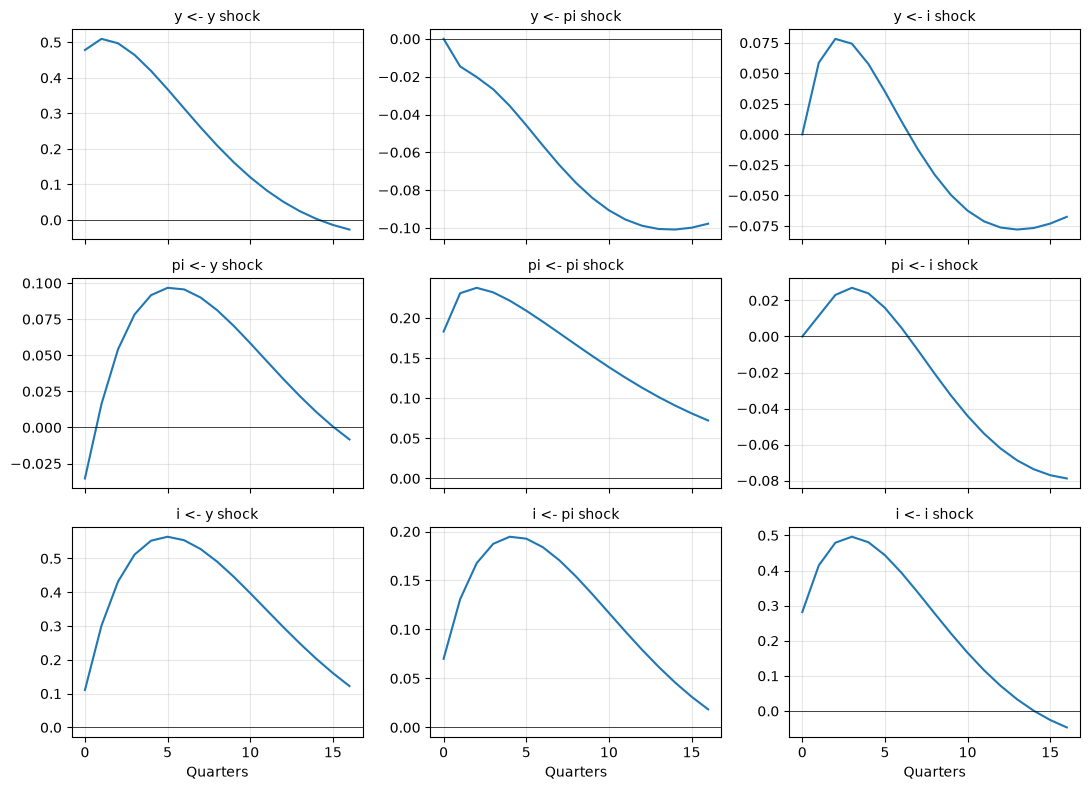

,h=1,h=4,h=8,h=16
y <- y,0.993,0.982,0.974,0.909
y <- pi,0.000,0.002,0.012,0.055
y <- i,0.007,0.016,0.014,0.036
pi <- y,0.017,0.071,0.118,0.109
pi <- pi,0.981,0.922,0.876,0.832
pi <- i,0.001,0.007,0.006,0.059
i <- y,0.274,0.442,0.534,0.588
i <- pi,0.059,0.064,0.066,0.066
i <- i,0.668,0.494,0.400,0.347


In [ ]:
IRF_H = 16
irf = svar.irf(horizon=IRF_H)                      # (horizon + 1, variable, shock)
h = np.arange(IRF_H + 1)

fig, axes = plt.subplots(3, 3, figsize=(11, 8), sharex=True)
for r, response in enumerate(NAMES):
    for c, shock in enumerate(NAMES):
        ax = axes[r, c]
        ax.plot(h, irf[:, r, c], lw=1.5)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title(f"{response} <- {shock} shock", fontsize=10)
        ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel("Quarters")
show(fig, "irf_recursive_svar")

fevd = svar.fevd(horizon=IRF_H)                    # (horizon + 1, variable, shock); rows sum to one
fevd_table = pd.DataFrame(
    {f"h={k}": {f"{v} <- {s}": fevd[k, r, c] for r, v in enumerate(NAMES) for c, s in enumerate(NAMES)}
     for k in (1, 4, 8, IRF_H)}
)
display(fevd_table.round(3))

## Out-of-sample comparison: fitted linear environment vs. realized data

We evaluate how the estimated linear environment tracks realized macroeconomic dynamics after the
training window. This is presented as a **descriptive out-of-sample comparison**, not a claim of
structural stability across policy regimes (Lütkepohl, 2005).

### Out-of-sample window
The out-of-sample period begins at **2007Q3** and extends to the most recent available quarter. This split
allows a clean separation between estimation and evaluation, highlighting performance during and after
the Global Financial Crisis and subsequent regime changes. The out-of-sample observations come from the
same FRED responses (fetched once over the full span) and the same `FredHelpers.to_pd_series`
standardization step, which guarantees comparability between training and evaluation samples (Federal
Reserve Bank of St. Louis, n.d.; Sunder, 2025).

In [ ]:
print(df_oos.head(), "\n")
print("OOS span:", df_oos.index.min(), "→", df_oos.index.max(), "| rows:", len(df_oos))

               y       pi     i
date                           
2007Q3  1.213636  2.57376  5.07
2007Q4  1.338861  2.62239  4.50
2008Q1  0.406716  2.03211  3.18
2008Q2  0.527217  1.81848  2.09
2008Q3 -0.445713  2.02788  1.94 

OOS span: 2007Q3 → 2026Q2 | rows: 76


### Forecast construction (design choice)
Forecasts are generated using the restricted estimated coefficients. Unless explicitly stated otherwise,
the notebook uses **realized lagged values** as inputs rather than recursively feeding forecasted values
back into the lag structure. This choice isolates one-step mapping performance from multi-step error
accumulation.

Because the inflation equation contains contemporaneous $y_t$ under the recursive ordering, its fitted
value is **conditional on realized $y_t$**. In reduced-form terms that equals the one-step forecast plus
$a^\pi_{y,0}\,(y_t - \hat y_t)$, which is the closed form of the Waggoner–Zha conditional forecast that
`cultivars.forecast.conditional_forecast` computes in general; at horizon one it is applied directly.

The unrestricted fixed-coefficient environment is carried alongside the restricted one throughout, so
that the effect of the paper's lag restriction on out-of-sample tracking can be read off directly.

In [ ]:
# Coefficients of the restricted environment (dropped terms shown as 0.0)
coef_y = svar_fit.coef("y").to_dict()
coef_pi = svar_fit.coef("pi").to_dict()

for key, val in coef_y.items():
    print(f"y  | {key:8s}: {val:.4f}")
for key, val in coef_pi.items():
    print(f"pi | {key:8s}: {val:.4f}")

y  | const   : 0.3070
y  | y_lag1  : 0.9775
y  | y_lag2  : 0.0000
y  | pi_lag1 : -0.0228
y  | pi_lag2 : 0.0000
y  | i_lag1  : -0.0499
y  | i_lag2  : 0.0000
pi | const   : 0.1275
pi | y       : -0.0642
pi | y_lag1  : 0.2086
pi | y_lag2  : -0.1094
pi | pi_lag1 : 1.2914
pi | pi_lag2 : -0.3150
pi | i_lag1  : -0.0169
pi | i_lag2  : 0.0000


In [ ]:
def one_step_from(v, s, X: np.ndarray, t: int) -> tuple[float, float]:
    """One-step ``(y_hat, pi_hat)`` at row ``t`` from a fitted VAR and its recursive identification.

    Uses realized lags only; ``pi_hat`` is conditional on the realized ``y_t`` through the
    contemporaneous structural coefficient implied by the impact matrix.
    """
    c = np.asarray(v.deterministic)[0]                      # constants, one per equation
    pred = c + sum(v.coefficients[lag] @ X[t - 1 - lag] for lag in range(v.order))
    a_y0 = float(s.impact[1, 0] / s.impact[0, 0])
    return float(pred[0]), float(pred[1] + a_y0 * (X[t, 0] - pred[0]))


def one_step(v, s, frame: pd.DataFrame, start: str) -> pd.DataFrame:
    """One-step fitted ``(y_hat, pi_hat)`` from ``start`` on, with fixed coefficients ``v``, ``s``."""
    X = frame[NAMES].to_numpy(dtype=float)
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    first = max(frame.index.get_loc(pd.Period(start, "Q")), v.order)
    for t in range(first, len(frame)):
        out.iloc[t, 0], out.iloc[t, 1] = one_step_from(v, s, X, t)
    return out


# Restricted environment: predictions on the structural design over training + OOS
_, X_y_all, _, X_pi_all = structural_design(df_all)
fixed = pd.DataFrame(index=df_all.index)
fixed["y_hat"] = svar_fit.mod_y.predict(X_y_all)
fixed["pi_hat"] = svar_fit.mod_pi.predict(X_pi_all)

# Unrestricted environment: cultivars reduced form + Cholesky (and the equivalent structural OLS)
unres = one_step(var, svar, df_all, TRAIN_START)
fixed["y_hat_unres"] = unres["y_hat"]
fixed["pi_hat_unres"] = unres["pi_hat"]
_valid = unres.dropna().index
assert np.allclose(unres.loc[_valid, "y_hat"], svar_fit.full_y.predict(X_y_all).loc[_valid])
assert np.allclose(unres.loc[_valid, "pi_hat"], svar_fit.full_pi.predict(X_pi_all).loc[_valid])

df_fixed = df_all.join(fixed)
oos_fixed = df_fixed.loc[OOS_START:]
assert not oos_fixed.isna().any().any()

for label, suffix in (("restricted", ""), ("unrestricted", "_unres")):
    for col in ("y", "pi"):
        e = oos_fixed[col] - oos_fixed[f"{col}_hat{suffix}"]
        print(f"OOS fixed-coefficient SVAR(2), {label:12s} | {col:2s}: "
              f"MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

OOS fixed-coefficient SVAR(2), restricted   | y : MSE=1.8339, RMSE=1.3542, n=76
OOS fixed-coefficient SVAR(2), restricted   | pi: MSE=0.2941, RMSE=0.5423, n=76
OOS fixed-coefficient SVAR(2), unrestricted | y : MSE=1.8062, RMSE=1.3440, n=76
OOS fixed-coefficient SVAR(2), unrestricted | pi: MSE=0.3004, RMSE=0.5481, n=76


### Out-of-sample tracking: output gap and inflation
The figures compare realized $y_t$ and $\pi_t$ (2007Q3 onward) to the one-step fitted values of the
restricted environment; the unrestricted environment is shown as a thin dotted line for reference.

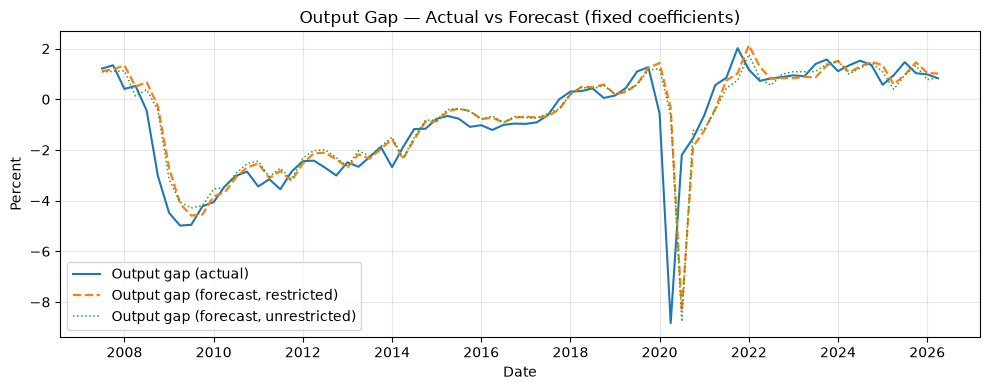

In [ ]:
def plot_actual_vs_fit(frame: pd.DataFrame, col: str, fits: dict[str, str], *, title: str, name: str,
                       bands: tuple[str, str] | None = None, band_label: str = "90% posterior band") -> None:
    """Realized series against one or more fitted columns (first fit dashed, later fits dotted)."""
    fig, ax = plt.subplots()
    x = frame.index.to_timestamp()
    ax.plot(x, frame[col], label=f"{'Output gap' if col == 'y' else 'Inflation YoY'} (actual)")
    for k, (label, fit_col) in enumerate(fits.items()):
        ax.plot(x, frame[fit_col], "--" if k == 0 else ":", lw=1.6 if k == 0 else 1.1, label=label)
    if bands is not None:
        ax.fill_between(x, frame[bands[0]], frame[bands[1]], alpha=0.15, label=band_label)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Percent")
    ax.grid(True, alpha=0.3)
    ax.legend()
    show(fig, name)


plot_actual_vs_fit(oos_fixed, "y", {"Output gap (forecast, restricted)": "y_hat",
                                    "Output gap (forecast, unrestricted)": "y_hat_unres"},
                   title="Output Gap — Actual vs Forecast (fixed coefficients)", name="oos_fixed_y")

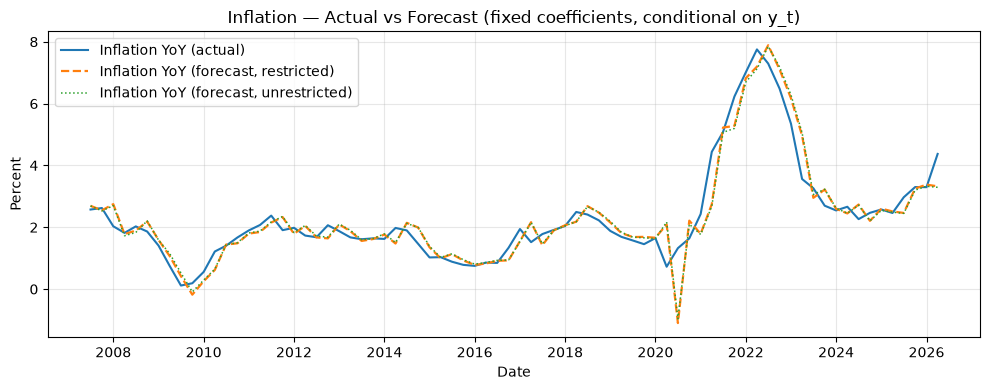

In [ ]:
plot_actual_vs_fit(oos_fixed, "pi", {"Inflation YoY (forecast, restricted)": "pi_hat",
                                     "Inflation YoY (forecast, unrestricted)": "pi_hat_unres"},
                   title="Inflation — Actual vs Forecast (fixed coefficients, conditional on y_t)",
                   name="oos_fixed_pi")

## In-sample fit and error diagnostics

To benchmark the linear environment on the estimation sample, we compute fitted values and squared errors
for both equations. These diagnostics indicate whether the restricted SVAR captures the primary short-run
dynamics within the training window (Lütkepohl, 2005).

In [ ]:
# Predict on the exact in-sample design matrices used in estimation
y_fit = svar_fit.mod_y.predict(svar_fit.mod_y.design)
pi_fit = svar_fit.mod_pi.predict(svar_fit.mod_pi.design)
assert y_fit.index.equals(svar_fit.mod_y.design.index)
assert pi_fit.index.equals(svar_fit.mod_pi.design.index)

# Build an aligned frame on the training index
fit_df = pd.DataFrame(index=df_train.index)
fit_df["y_actual"] = df_train["y"]
fit_df["pi_actual"] = df_train["pi"]
fit_df["y_fit"] = y_fit.reindex(fit_df.index)
fit_df["pi_fit"] = pi_fit.reindex(fit_df.index)

# Residuals and squared errors (in-sample)
resid_y = fit_df["y_actual"] - fit_df["y_fit"]
resid_pi = fit_df["pi_actual"] - fit_df["pi_fit"]
fit_df["se_y_svar"] = resid_y**2
fit_df["se_pi_svar"] = resid_pi**2

# Drop rows without a fitted value (initial lags)
fit_df = fit_df.dropna(subset=["y_fit", "pi_fit"])

# Quick diagnostics
print(fit_df[["se_y_svar", "se_pi_svar"]].head())
print("In-sample std(resid):", round(resid_y.dropna().std(), 3), round(resid_pi.dropna().std(), 3))

        se_y_svar  se_pi_svar
date                         
1988Q1   0.015276    0.000237
1988Q2   0.442241    0.120509
1988Q3   0.000026    0.107042
1988Q4   0.633361    0.002650
1989Q1   0.279251    0.065931
In-sample std(resid): 0.472 0.178


In [ ]:
def plot_se(frame: pd.DataFrame, col: str, *, title: str, label: str, name: str) -> None:
    """Squared-error diagnostic in the style of the paper's Figures 4 and 5."""
    fig, ax = plt.subplots()
    ax.plot(frame.index.to_timestamp(), frame[col], color="red", lw=1.5, label=label)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Squared error")
    ax.grid(False)
    ax.legend()
    show(fig, name)

### Figure 4 Output Gap Fit: Squared Errors

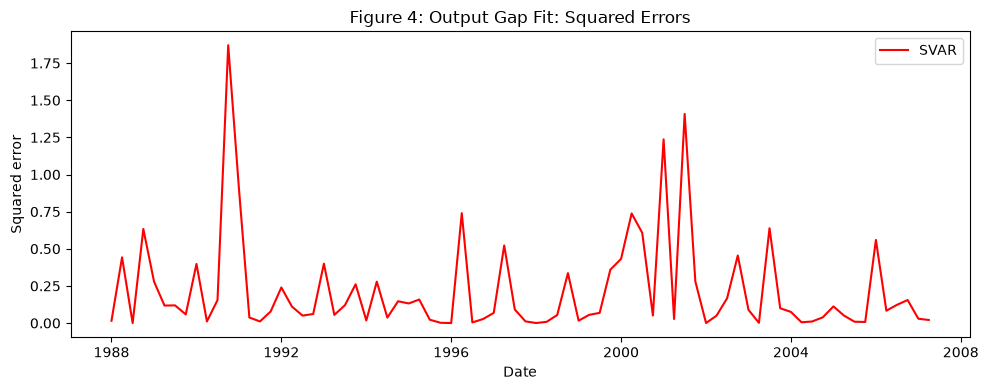

In [ ]:
plot_se(fit_df, "se_y_svar", title="Figure 4: Output Gap Fit: Squared Errors", label="SVAR", name="fig4_baseline")

### Figure 5 Inflation Fit: Squared Errors

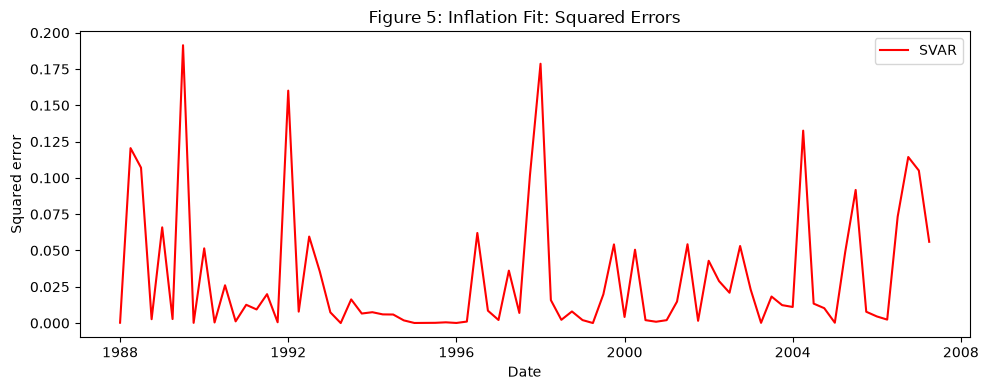

In [ ]:
plot_se(fit_df, "se_pi_svar", title="Figure 5: Inflation Fit: Squared Errors", label="SVAR", name="fig5_baseline")

Note: The y-axis scale is different from the paper due to our model using the correct units (YoY
percent, not decimals). In addition, the smaller squared errors reflect a tighter fit in the replication
relative to the Bundesbank baseline.

--------

# Alternative Specification: Rolling-Window SVAR(2) (Unrestricted)

This section estimates a robustness variant of the baseline linear environment. Instead of restricting
the SVAR(2) by dropping statistically weak second-lag terms, we estimate an **unrestricted SVAR(2)** on a
**rolling window**. The rolling-window design allows the effective law of motion to vary over time by
re-estimating parameters on a moving subsample, which is a standard device when forecast performance
may be affected by **structural change** or **parameter instability** (Clements & Hendry, 1998; Stock &
Watson, 2007). Identification follows the same recursive ordering used in the baseline SVAR (Sims, 1980;
Lütkepohl, 2005), declared through `RecursiveSVAR` on every window.

## Data (unchanged)

The observable definitions and transformations are unchanged relative to the baseline specification. The
rolling loop works from the same quarterly panel (`df_all`, 1987Q3 to the latest observation) that was
built above from the standardized FRED responses; no series is re-fetched (Federal Reserve Bank of St.
Louis, n.d.; Sunder, 2025).

## Rolling estimation design

### Window length and evaluation period

Let $W$ denote the rolling window length in quarters. In this alternative specification we use
$W = 40$ (ten years) **throughout**.

For each evaluation quarter $t$, the SVAR(2) is estimated on the trailing subsample $[t-W,\;t-1]$, and
one-step-ahead fitted values $(\hat y_t,\hat\pi_t)$ are computed using realized regressors. This produces
a time series of locally re-estimated parameters $\{\hat\theta_t\}$ and fitted values that can adapt to
changing reduced-form relationships.

**On the window length.** An earlier version of this exercise used $W = 4$. Each equation has seven
regressors and a two-lag VAR loses two rows to lags, so a four-quarter window leaves two observations for
seven coefficients: the OLS problem is rank-deficient and any fitted values it produces are artefacts of
the pseudo-inverse. `cultivars` refuses that specification (a VAR(2) in three variables needs at least
ten rows to be estimable and eleven for a non-singular residual covariance). $W = 40$ gives 38 effective
observations per window, enough for the coefficients to be determined by the data while still allowing
the law of motion to drift across a decade; the window-length sensitivity table at the end of this
section shows how estimation noise grows as $W$ is shortened.

### Rolling sample and no-look-ahead rule

For each quarter $t$, the rolling SVAR(2) is estimated using only the trailing subsample $[t-W,\;t-1]$
with $W=40$. This enforces a strict **no-look-ahead** rule: parameters used to form $(\hat y_t,\hat\pi_t)$
depend only on information available prior to quarter $t$.

Implementation-wise, the rolling code requires a single quarterly panel containing $\pi_t$, $y_t$, and
$i_t$ over the span where rolling fitted values are desired. The notebook uses a quarterly `PeriodIndex`
so that lag operations ($t-1$, $t-2$) are well-defined; within the loop the panel is addressed by
integer position for speed.

### Implementation: Rolling Unrestricted SVAR(2)

In [ ]:
W = 40                                              # rolling window, quarters
MIN_WINDOW = 11                                     # smallest window with a non-singular residual covariance
assert W >= MIN_WINDOW, f"VAR(2) in three variables needs at least {MIN_WINDOW} rows"


def fit_unrestricted_svar_window(sample: np.ndarray):
    """Fit the unrestricted recursive SVAR(2) on one window (no lag dropping).

    Multivariate least squares on the reduced form is equation-by-equation OLS; the recursive
    identification supplies the contemporaneous structural coefficient.

    Returns:
        ``(VARResult, SVARResult)``.
    """
    v = VAR(sample, order=2, trend="c", names=NAMES).fit()
    s = RecursiveSVAR(v, order=NAMES).identify()
    return v, s


def rolling_one_step(frame: pd.DataFrame, window: int, start: str) -> pd.DataFrame:
    """One-step fitted ``(y_hat, pi_hat)`` from ``start`` on, re-estimating on the trailing ``window``."""
    X = frame[NAMES].to_numpy(dtype=float)
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    first = max(frame.index.get_loc(pd.Period(start, "Q")), window)
    for t in range(first, len(frame)):
        v, s = fit_unrestricted_svar_window(X[t - window : t])
        out.iloc[t, 0], out.iloc[t, 1] = one_step_from(v, s, X, t)
    return out

### Estimation details (unrestricted, equation-by-equation)

Within each rolling window, both equations are estimated by least squares **without** post-estimation
lag selection. That is, all first- and second-lag regressors are retained in every window:

- Output-gap equation regressors: $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- Inflation equation regressors: $(y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$

This differs from the baseline specification, where the second-lag terms may be dropped based on
full-sample significance. Here, coefficient variation is driven by **window re-estimation** rather than
explicit restriction.

## Unrestricted recursive SVAR(2)

Let the state vector include output gap $y_t$, inflation $\pi_t$, and the policy rate $i_t$. The rolling
specification retains the same recursive ordering as the baseline, while **retaining all first- and
second-lag regressors** (no lag dropping).

1. **Output-gap equation (reduced form)**
$$
y_t = C^y + a^y_{y,1}y_{t-1} + a^y_{y,2}y_{t-2}
      + a^y_{\pi,1}\pi_{t-1} + a^y_{\pi,2}\pi_{t-2}
      + a^y_{i,1}i_{t-1} + a^y_{i,2}i_{t-2} + \varepsilon^y_t.
$$

2. **Inflation equation (recursive ordering)**
$$
\pi_t = C^\pi + a^\pi_{y,0}y_{t} + a^\pi_{y,1}y_{t-1} + a^\pi_{y,2}y_{t-2}
        + a^\pi_{\pi,1}\pi_{t-1} + a^\pi_{\pi,2}\pi_{t-2}
        + a^\pi_{i,1}i_{t-1} + a^\pi_{i,2}i_{t-2} + \varepsilon^\pi_t.
$$

Each equation is estimated by least squares within the rolling window. The recursive contemporaneous
term $y_t$ in the inflation equation corresponds to a standard triangular (Cholesky-style) ordering used in
VAR/SVAR applications (Sims, 1980; Lütkepohl, 2005).

## Rolling fit diagnostics

With rolling estimation using $W=40$, the core diagnostics are:

- **In-sample (1987Q3–2007Q2):** squared errors from the rolling fitted values (Figures 4–5, Alt Spec).
  Because the first window must be filled before any fitted value exists, in-sample rolling fits start
  ten years into the training window (1997Q3).
- **Out-of-sample (2007Q3 onward):** actual vs. rolling fitted values and squared errors computed from
  the rolling loop.

Squared errors are defined as:
$$
SE^y_t = (y_t - \hat y_t)^2,\qquad SE^\pi_t = (\pi_t - \hat\pi_t)^2.
$$

Summaries (mean squared error and its root) are reported over both evaluation subsamples.

In [ ]:
# Rolling one-step fits over training + OOS (one pass; sliced afterwards)
roll_all = df_all.join(rolling_one_step(df_all, W, TRAIN_START))
roll_is = roll_all.loc[:TRAIN_END].dropna()
roll_oos = roll_all.loc[OOS_START:].dropna()

for label, frame in (("in-sample", roll_is), ("OOS", roll_oos)):
    for col in ("y", "pi"):
        e = frame[col] - frame[f"{col}_hat"]
        print(f"{label:9s} rolling W={W} | {col:2s}: MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

roll_is["se_y_roll_is"] = (roll_is["y"] - roll_is["y_hat"]) ** 2
roll_is["se_pi_roll_is"] = (roll_is["pi"] - roll_is["pi_hat"]) ** 2

in-sample rolling W=40 | y : MSE=0.3363, RMSE=0.5799, n=40
in-sample rolling W=40 | pi: MSE=0.0426, RMSE=0.2063, n=40
OOS       rolling W=40 | y : MSE=7.8952, RMSE=2.8098, n=76
OOS       rolling W=40 | pi: MSE=0.2665, RMSE=0.5162, n=76


### Figure 4 (Alt Spec, In-Sample): Output Gap Fit — Squared Errors (Rolling, $W=40$)

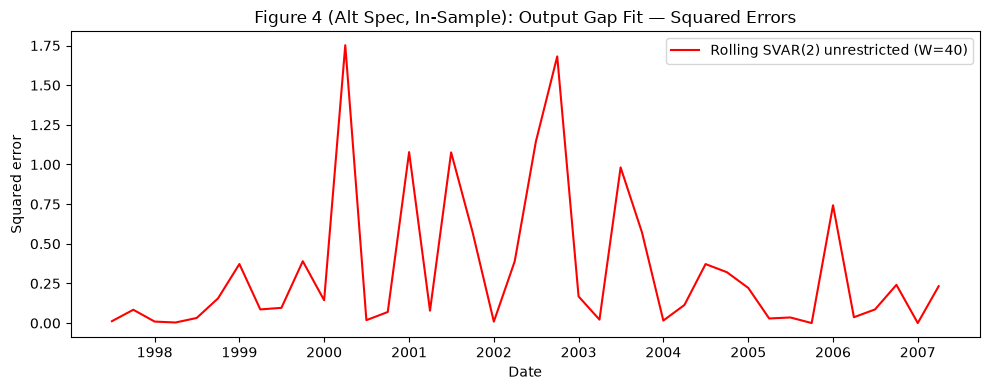

In [ ]:
plot_se(roll_is, "se_y_roll_is", title="Figure 4 (Alt Spec, In-Sample): Output Gap Fit — Squared Errors",
        label=f"Rolling SVAR(2) unrestricted (W={W})", name="fig4_rolling")

### Figure 5 (Alt Spec, In-Sample): Inflation Fit — Squared Errors (Rolling, $W=40$, conditional $\hat\pi_t$)

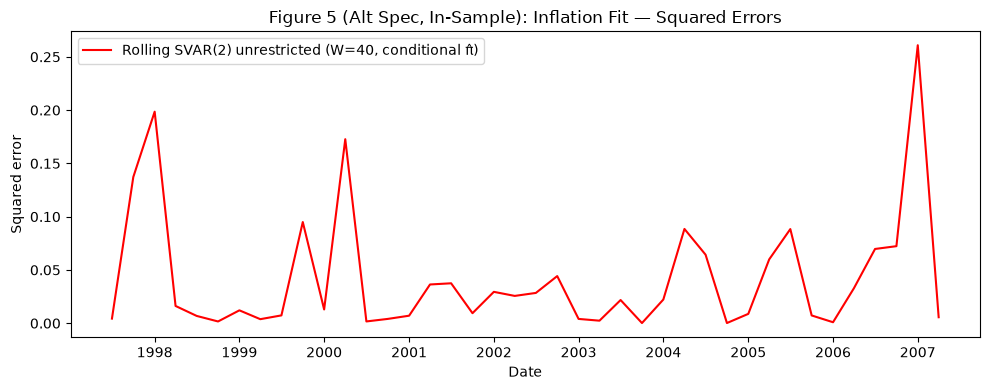

In [ ]:
plot_se(roll_is, "se_pi_roll_is", title="Figure 5 (Alt Spec, In-Sample): Inflation Fit — Squared Errors",
        label=f"Rolling SVAR(2) unrestricted (W={W}, conditional π̂)", name="fig5_rolling")

**Interpretation note (rolling window):** With $W=40$, each window contains 38 effective observations for
seven coefficients per equation, so the local estimates are determined by the data but remain
considerably noisier than the full-sample baseline. These plots are therefore best read as a diagnostic
for **time variation / instability** under re-estimation rather than as a precision-optimized fit
measure.

## Forecast construction and interpretation

### One-step-ahead mapping
For each quarter $t$, we compute one-step fitted values using the coefficients estimated on
$[t-W,\,t-1]$. Unless explicitly stated otherwise, the regressors are formed from **realized** lagged
values $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$. This isolates the quality of the
local linear mapping from the accumulation of multi-step forecast error.

### Conditional vs. fully model-based inflation prediction
Because the recursive ordering includes contemporaneous $y_t$ in the inflation equation, $\hat \pi_t$ can
be computed either:
- **Conditionally**, using the realized $y_t$ (interpretable as a partial-equilibrium or conditional
  forecast), or
- **Fully model-based**, substituting $y_t$ with $\hat y_t$ from the rolling output-gap equation.

The notebook reports the conditional version by default to separate coefficient drift from feedback
error introduced by recursive substitution.

### Forecast inputs used in the rolling loop

The rolling loop produces one-step-ahead fitted values using **realized lagged inputs** from the data:

- $\hat y_t$ uses $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$.
- $\hat\pi_t$ is computed **conditionally** using realized contemporaneous $y_t$ (i.e., the recursive
  term is treated as observed).

The conditional inflation fit isolates variation coming from rolling coefficients and lag dynamics, and
avoids additional error propagation that would occur if $y_t$ were replaced by $\hat y_t$ inside the
inflation equation.

## Out-of-sample evaluation (Rolling SVAR(2), unrestricted, $W=40$)

We evaluate the rolling-window SVAR(2) on the post-training period starting in **2007Q3**. For each
quarter $t$, model parameters are re-estimated using only the trailing subsample $[t-W,\;t-1]$ with
$W=40$, and one-step-ahead fitted values $(\hat y_t,\hat\pi_t)$ are constructed using **realized** lagged
inputs. With a ten-year window the first out-of-sample quarter already has a full estimation window
behind it, so fitted values exist for every out-of-sample observation.

In [ ]:
# Out-of-sample: actual vs rolling SVAR(2) fitted (W=40)
oos_roll = roll_oos.copy()
oos_roll["err_y_roll"] = oos_roll["y"] - oos_roll["y_hat"]
oos_roll["err_pi_roll"] = oos_roll["pi"] - oos_roll["pi_hat"]
oos_roll["se_y_roll"] = oos_roll["err_y_roll"] ** 2
oos_roll["se_pi_roll"] = oos_roll["err_pi_roll"] ** 2

mse_y_roll = float(oos_roll["se_y_roll"].mean())
mse_pi_roll = float(oos_roll["se_pi_roll"].mean())
print(f"OOS (from {OOS_START}) Rolling W={W} | y:  MSE={mse_y_roll:.4f}, RMSE={mse_y_roll**0.5:.4f}, n={len(oos_roll)}")
print(f"OOS (from {OOS_START}) Rolling W={W} | pi: MSE={mse_pi_roll:.4f}, RMSE={mse_pi_roll**0.5:.4f}, n={len(oos_roll)}")

OOS (from 2007Q3) Rolling W=40 | y:  MSE=7.8952, RMSE=2.8098, n=76
OOS (from 2007Q3) Rolling W=40 | pi: MSE=0.2665, RMSE=0.5162, n=76


### Out-of-sample tracking: output gap ($y_t$)

The figure compares the realized output gap $y_t$ to the rolling SVAR fitted value $\hat y_t$ for the
out-of-sample period (2007Q3 onward). This is a descriptive assessment of how the locally re-estimated
linear mapping tracks realized dynamics under potential structural change.

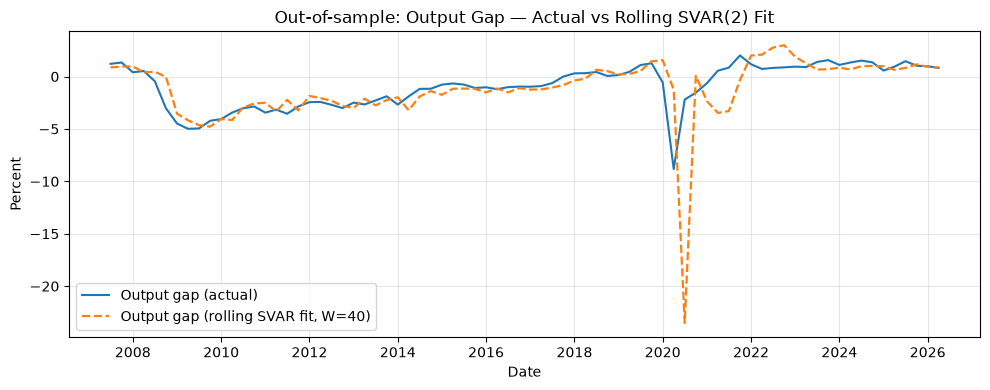

In [ ]:
plot_actual_vs_fit(oos_roll, "y", {f"Output gap (rolling SVAR fit, W={W})": "y_hat"},
                   title="Out-of-sample: Output Gap — Actual vs Rolling SVAR(2) Fit", name="oos_rolling_y")

### Out-of-sample tracking: inflation ($\pi_t$, conditional fit)

Because the recursive ordering includes contemporaneous $y_t$ in the inflation equation, the rolling
inflation fitted value $\hat\pi_t$ is computed **conditionally** using realized $y_t$ (rather than
substituting $\hat y_t$). This choice isolates coefficient drift and lag dynamics from additional error
propagation due to recursive substitution.

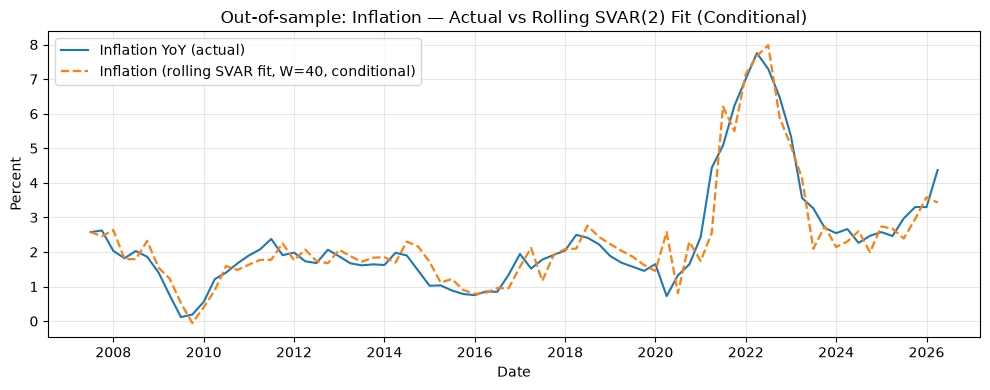

In [ ]:
plot_actual_vs_fit(oos_roll, "pi", {f"Inflation (rolling SVAR fit, W={W}, conditional)": "pi_hat"},
                   title="Out-of-sample: Inflation — Actual vs Rolling SVAR(2) Fit (Conditional)",
                   name="oos_rolling_pi")

### Out-of-sample error metrics

For completeness, we summarize out-of-sample performance using mean squared error (MSE) and root mean
squared error (RMSE) over the post-2007Q3 subsample where rolling fitted values are available:
$$
\text{MSE}^m = \frac{1}{T}\sum_t (x_t^m-\hat x_t^m)^2,\qquad
\text{RMSE}^m = \sqrt{\text{MSE}^m},\quad m\in\{y,\pi\}.
$$
These metrics are reported separately for the output gap and inflation series.

### Window-length sensitivity

The rolling design trades adaptivity against estimation noise. The table reports out-of-sample RMSE for
several window lengths; the baseline $W = 40$ is included for reference. Shorter windows track the
post-2007 regimes more closely only if the gain in adaptivity outweighs the loss of precision, which the
numbers below make explicit.

In [ ]:
WINDOWS = (20, 30, 40, 60)
sensitivity = {}
for w in WINDOWS:
    frame = df_all.join(rolling_one_step(df_all, w, OOS_START)).loc[OOS_START:].dropna()
    sensitivity[f"W={w}"] = {
        "RMSE y": float(np.sqrt(np.mean((frame["y"] - frame["y_hat"]) ** 2))),
        "RMSE pi": float(np.sqrt(np.mean((frame["pi"] - frame["pi_hat"]) ** 2))),
        "n": len(frame),
    }
sens_tab = pd.DataFrame(sensitivity).T
sens_tab["n"] = sens_tab["n"].astype(int)
display(sens_tab.round(4))

,RMSE y,RMSE pi,n
W=20,5.5999,0.8851,76
W=30,3.1467,0.5312,76
W=40,2.8098,0.5162,76
W=60,1.9294,0.4839,76


## What this robustness check evaluates

Relative to a fixed-parameter SVAR estimated on a long pre-crisis window, rolling estimation tests whether
allowing parameters to adapt improves descriptive out-of-sample tracking when the economy undergoes
regime shifts (e.g., the Global Financial Crisis and the effective lower bound period). Evidence that the
rolling SVAR improves fit is consistent with time variation in reduced-form relationships, a common
explanation for macro forecast instability (Stock & Watson, 2007; Clements & Hendry, 1998).

### Interpretation caveats

Rolling estimation trades off flexibility and precision: using shorter windows can adapt to structural
change, but increases sampling variation in the coefficient estimates. Accordingly, improvements in
rolling tracking should be interpreted as evidence consistent with **time variation in reduced-form
relationships**, not as structural identification or policy-invariance.

--------

# Modified Alternative Specification: Expanding-Window SVAR(2) (Unrestricted)

This section estimates an additional robustness variant of the linear environment using an
expanding-window recursive SVAR(2) (Sims, 1980; Lütkepohl, 2005). Relative to the rolling-window
specification, the expanding-window design re-estimates the same unrestricted recursive SVAR(2) each
quarter (Hamilton, 1994) using all data available from the initial estimation start through quarter
$t-1$. This preserves the no-look-ahead rule while allowing the effective estimation sample to grow over
time.

The expanding-window design is useful when coefficient instability may still matter, but the rolling
window is judged too short and therefore too noisy. In this setup, parameters are allowed to update as new
data arrive, while estimation precision improves over time because each successive regression is fit on a
larger sample.

## Expanding-window estimation design

Let $t_0$ denote the first quarter in the available sample and let $t$ denote the forecast quarter. For
each quarter $t$, the recursive SVAR(2) is estimated on the full historical subsample

$$
[t_0,\, t-1].
$$

This corresponds to recursive (expanding-window) estimation in the sense of Hamilton (1994), where the
information set grows monotonically over time.

Unlike the rolling-window specification, no observations are discarded once they enter the estimation
sample, in contrast to rolling-window estimation, which uses a fixed-length subsample (Giacomini & White,
2006). Thus, the coefficient estimates evolve through recursive re-estimation on an expanding information
set rather than through repeated estimation on a fixed-length moving window.

As in the rolling specification, the model remains unrestricted: all first- and second-lag regressors are
retained in both equations, and inflation is computed conditionally using realized contemporaneous $y_t$
under the recursive ordering. The first estimation uses twelve quarters (1987Q3–1990Q2), the smallest
sample on which the three-variable VAR(2) is comfortably estimable; earlier fitted values would be
dominated by estimation noise.

## Recursive unrestricted SVAR(2)

The expanding-window specification retains the same recursive reduced-form system used in the rolling
specification:

1. Output-gap equation
$$
y_t = C^y + a^y_{y,1} y_{t-1} + a^y_{y,2} y_{t-2}
      + a^y_{\pi,1} \pi_{t-1} + a^y_{\pi,2} \pi_{t-2}
      + a^y_{i,1} i_{t-1} + a^y_{i,2} i_{t-2} + \varepsilon^y_t.
$$

2. Inflation equation
$$
\pi_t = C^\pi + a^\pi_{y,0} y_t + a^\pi_{y,1} y_{t-1} + a^\pi_{y,2} y_{t-2}
        + a^\pi_{\pi,1} \pi_{t-1} + a^\pi_{\pi,2} \pi_{t-2}
        + a^\pi_{i,1} i_{t-1} + a^\pi_{i,2} i_{t-2} + \varepsilon^\pi_t.
$$

This recursive identification scheme follows the standard triangular (Cholesky-style) ordering commonly
used in SVAR models (Sims, 1980; Lütkepohl, 2005).

The only change relative to the rolling-window specification is the estimation window. Forecast
construction, recursive ordering, and regressor timing remain unchanged.

## Forecast construction and interpretation

For each quarter $t$, one-step-ahead fitted values are computed using coefficients estimated on the
expanding sample ending at $t-1$. This corresponds to recursive real-time forecasting using expanding
information sets (Hamilton, 1994). As in the earlier sections, realized lagged values are used to form the
regressors. Thus:

- $\hat y_t$ uses realized $(y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- $\hat \pi_t$ is computed conditionally using realized contemporaneous $y_t$

This keeps the expanding-window results directly comparable to both the fixed-parameter baseline and the
rolling-window SVAR, while avoiding additional multi-step feedback error.

In [ ]:
MIN_EXPANDING = 12                                  # first estimation sample, quarters


def expanding_one_step(frame: pd.DataFrame, start: str, *, minimum: int = MIN_EXPANDING) -> pd.DataFrame:
    """One-step fitted ``(y_hat, pi_hat)`` from ``start`` on, re-estimating on all data through ``t-1``."""
    X = frame[NAMES].to_numpy(dtype=float)
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    first = max(frame.index.get_loc(pd.Period(start, "Q")), minimum)
    for t in range(first, len(frame)):
        v, s = fit_unrestricted_svar_window(X[:t])
        out.iloc[t, 0], out.iloc[t, 1] = one_step_from(v, s, X, t)
    return out


exp_all = df_all.join(expanding_one_step(df_all, TRAIN_START))
exp_is = exp_all.loc[:TRAIN_END].dropna()
exp_oos = exp_all.loc[OOS_START:].dropna()

exp_is["se_y_expand_is"] = (exp_is["y"] - exp_is["y_hat"]) ** 2
exp_is["se_pi_expand_is"] = (exp_is["pi"] - exp_is["pi_hat"]) ** 2

print(f"In-sample expanding SVAR(2) | y:  MSE={exp_is['se_y_expand_is'].mean():.4f}, "
      f"RMSE={exp_is['se_y_expand_is'].mean()**0.5:.4f}, n={len(exp_is)}")
print(f"In-sample expanding SVAR(2) | pi: MSE={exp_is['se_pi_expand_is'].mean():.4f}, "
      f"RMSE={exp_is['se_pi_expand_is'].mean()**0.5:.4f}, n={len(exp_is)}")

In-sample expanding SVAR(2) | y:  MSE=0.5066, RMSE=0.7118, n=68
In-sample expanding SVAR(2) | pi: MSE=0.0726, RMSE=0.2695, n=68


## In-sample fit diagnostics

To compare the expanding-window SVAR(2) to the baseline and rolling alternatives, we compute one-step-ahead
fitted values and squared errors over the training period. Because the estimation sample expands
recursively, the earliest in-sample fitted values are based on smaller subsamples, while later fitted
values reflect increasingly stable parameter estimates.

As in the previous sections, the plotted squared errors should be read as descriptive diagnostics of fit
rather than as formal forecast-evaluation statistics in the sense of Giacomini & White (2006); the formal
tests follow in the next section.

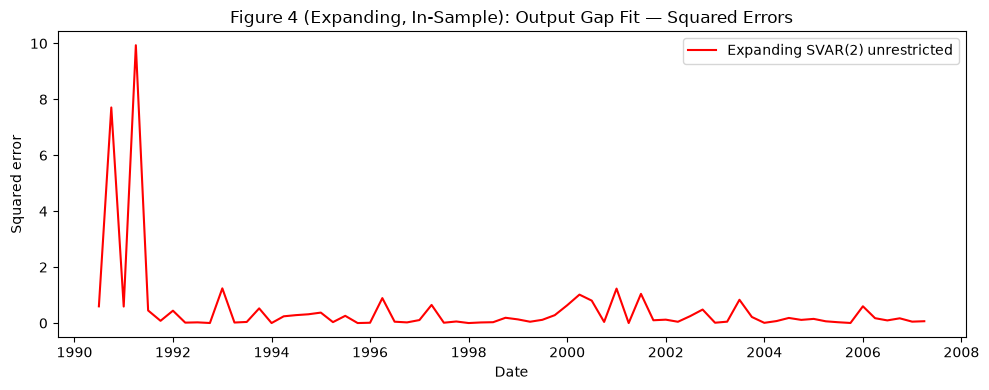

In [ ]:
plot_se(exp_is, "se_y_expand_is", title="Figure 4 (Expanding, In-Sample): Output Gap Fit — Squared Errors",
        label="Expanding SVAR(2) unrestricted", name="fig4_expanding")

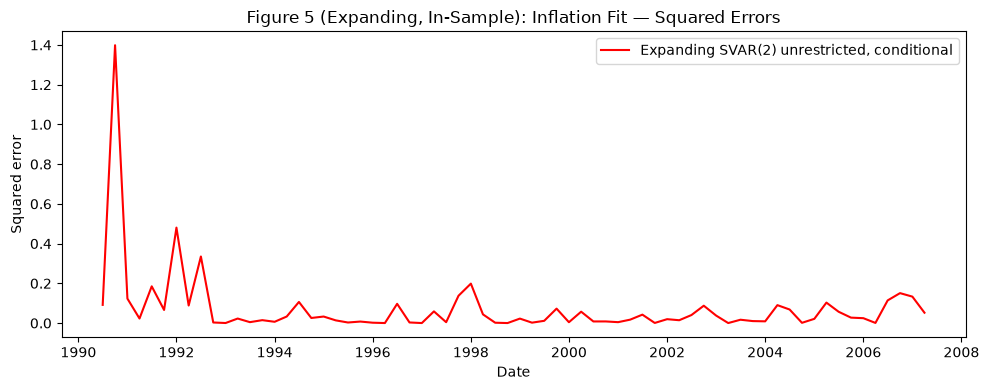

In [ ]:
plot_se(exp_is, "se_pi_expand_is", title="Figure 5 (Expanding, In-Sample): Inflation Fit — Squared Errors",
        label="Expanding SVAR(2) unrestricted, conditional", name="fig5_expanding")

## Out-of-sample evaluation

We next evaluate the expanding-window SVAR(2) over the post-training period beginning in 2007Q3. For each
quarter $t$, coefficients are re-estimated using all data available through quarter $t-1$, and
one-step-ahead fitted values are constructed using realized lagged regressors.

This recursive re-estimation scheme corresponds to expanding-window forecast evaluation, as opposed to
rolling-window evaluation (Giacomini & White, 2006).

Relative to the fixed-parameter baseline, the expanding-window specification allows coefficients to update
as new information arrives. Relative to the rolling-window specification, it avoids discarding earlier
observations and therefore typically produces smoother, less noisy coefficient estimates.

In [ ]:
oos_expand = exp_oos.copy()
oos_expand["err_y_expand"] = oos_expand["y"] - oos_expand["y_hat"]
oos_expand["err_pi_expand"] = oos_expand["pi"] - oos_expand["pi_hat"]
oos_expand["se_y_expand"] = oos_expand["err_y_expand"] ** 2
oos_expand["se_pi_expand"] = oos_expand["err_pi_expand"] ** 2

mse_y_expand = float(oos_expand["se_y_expand"].mean())
mse_pi_expand = float(oos_expand["se_pi_expand"].mean())
print(f"OOS expanding SVAR(2) | y:  MSE={mse_y_expand:.4f}, RMSE={mse_y_expand**0.5:.4f}, n={len(oos_expand)}")
print(f"OOS expanding SVAR(2) | pi: MSE={mse_pi_expand:.4f}, RMSE={mse_pi_expand**0.5:.4f}, n={len(oos_expand)}")

OOS expanding SVAR(2) | y:  MSE=2.8294, RMSE=1.6821, n=76
OOS expanding SVAR(2) | pi: MSE=0.2283, RMSE=0.4778, n=76


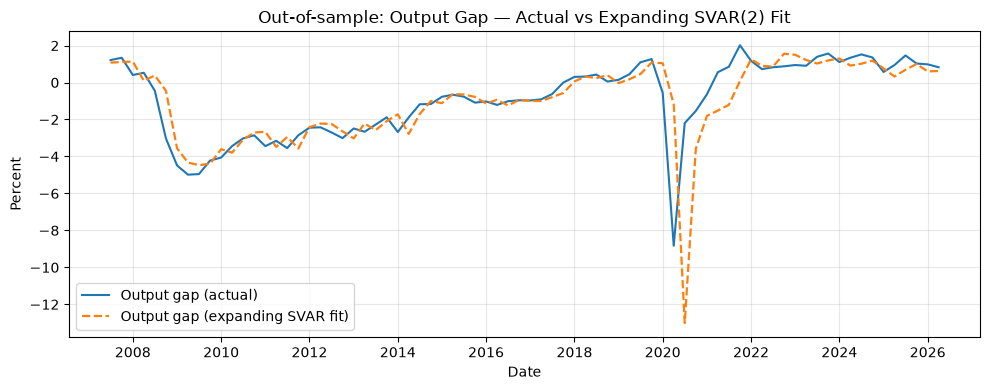

In [ ]:
plot_actual_vs_fit(oos_expand, "y", {"Output gap (expanding SVAR fit)": "y_hat"},
                   title="Out-of-sample: Output Gap — Actual vs Expanding SVAR(2) Fit", name="oos_expanding_y")

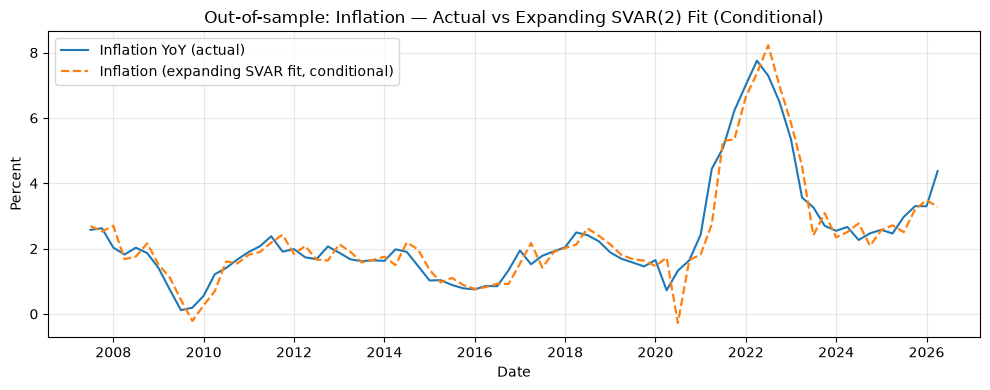

In [ ]:
plot_actual_vs_fit(oos_expand, "pi", {"Inflation (expanding SVAR fit, conditional)": "pi_hat"},
                   title="Out-of-sample: Inflation — Actual vs Expanding SVAR(2) Fit (Conditional)",
                   name="oos_expanding_pi")

--------

# Formal comparison of the re-estimation schemes (`cultivars.forecast`)

The paper's comparison of the re-estimation schemes is descriptive (MSE by eye). `cultivars.forecast`
turns the same exercise into a formal out-of-sample evaluation:

- `Backtest` re-runs the rolling ($W = 40$) and expanding schemes as rolling-origin forecasting exercises
  on the **unconditional** reduced-form VAR, re-estimated at every origin from 2007Q3, and records
  forecasts and outcomes origin by origin so that every downstream test reads aligned series.
- `ForecastComparison` tests the loss differential with Diebold–Mariano (1995), its
  Harvey–Leybourne–Newbold (1997) small-sample correction (the one to read on a window this short) and the
  Giacomini–White (2006) conditional test.

For the output gap, which is ordered first, the unconditional one-step forecast coincides with the
conditional fitted value used above, so the backtest RMSE must reproduce the loop's number exactly; for
inflation the backtest forecast is unconditional and therefore differs from the conditional fit by the
term $a^\pi_{y,0}(y_t - \hat y_t)$.

In [ ]:
start_index = df_all.index.get_loc(pd.Period(OOS_START, "Q"))


def fit_var(sample: np.ndarray):
    return VAR(sample, order=2, trend="c", names=NAMES).fit()


bt_rolling = Backtest(df_all[NAMES].to_numpy(), fit_var, horizons=1, start=start_index,
                      scheme="rolling", window=W, names=NAMES).run()
bt_expanding = Backtest(df_all[NAMES].to_numpy(), fit_var, horizons=1, start=start_index,
                        scheme="expanding", names=NAMES).run()
print(bt_rolling.summary())
print(bt_expanding.summary())

rmse_y_loop = {"rolling": mse_y_roll**0.5, "expanding": mse_y_expand**0.5}
rmse_y_bt = {"rolling": float(bt_rolling.rmse[0, 0]), "expanding": float(bt_expanding.rmse[0, 0])}
for scheme in ("rolling", "expanding"):
    print(f"{scheme:9s} | output-gap RMSE: loop={rmse_y_loop[scheme]:.4f}, backtest={rmse_y_bt[scheme]:.4f}, "
          f"consistent={np.isclose(rmse_y_loop[scheme], rmse_y_bt[scheme])}")

                                    Backtest
Origins:                            76  Horizons:                            1
Series:                              3  Scheme:                        rolling
Draws:                               0
--------------------------------------------------------------------------------
h     series     RMSE      MAE   mean CRPS
1          y   2.8098   1.0980           -
1         pi   0.5615   0.4003           -
1          i   0.5153   0.3301           -
Rolling scheme, 76 origins 1 apart, re-estimated at every origin; rolling window
of 40 observations.
Row t's h-step forecast is aligned with the outcome at origins[t] + h - 1;
losses(kind, horizon=h, name=...) hands the aligned series to a comparison test.
Point forecasts only: CRPS, log scores, and calibration need a result exposing
forecast_paths().
                                    Backtest
Origins:                            76  Horizons:                            1
Series:                    

In [ ]:
for name in NAMES[:2]:
    losses_rolling = bt_rolling.losses("squared", horizon=1, name=name)
    losses_expanding = bt_expanding.losses("squared", horizon=1, name=name)
    print(f"\n--- {name}: rolling W={W} (A) vs expanding (B), squared loss, h = 1 ---")
    print(ForecastComparison(losses_rolling, losses_expanding).compute(horizon=1).summary())


--- y: rolling W=40 (A) vs expanding (B), squared loss, h = 1 ---
                              Forecast Comparison
Origins:                            76  Horizon:                             1
Mean differential:            +5.06583
--------------------------------------------------------------------------------
test                              statistic   p-value
Diebold-Mariano                      1.1480    0.2510
Harvey-Leybourne-Newbold             1.1404    0.2578
Giacomini-White (conditional)        1.5168    0.4684
Mean loss differential +5.06583: the sign favors forecaster B (losses are
negatively oriented).
The HLN row is the DM statistic with the small-sample correction, referred to a
t distribution; in short evaluation windows it is the number to trust.
Giacomini-White asks whether the gap was *predictable* from a constant and the
differential lagged by the horizon; its framework wants rolling-window
estimation behind the losses.
These are tests about forecasts, not mode

## Model confidence set and forecast efficiency

Two further `cultivars` tools complete the comparison on the conditional one-step fits used throughout the
notebook, aligned origin by origin over 2007Q3 onward:

- `model_confidence_set` (Hansen, Lunde & Nason, 2011) asks which of the four real-time environments --
  fixed restricted, fixed unrestricted, rolling and expanding -- cannot be separated from the best at the
  90% level. It replaces a sequence of pairwise tests with one statement about the set of adequate
  models.
- `mincer_zarnowitz` (Mincer & Zarnowitz, 1969) regresses the outcome on each forecast and tests
  $(a, b) = (0, 1)$: an intercept away from zero is bias, a slope below one says the forecast overreacts
  and would gain from shrinkage toward its mean.

The smoothed TVP fit of the final section is not a real-time forecast and is deliberately left out of the
set.

In [ ]:
forecasters = {
    "fixed (restricted)": oos_fixed[["y", "pi", "y_hat", "pi_hat"]],
    "fixed (unrestricted)": oos_fixed[["y", "pi", "y_hat_unres", "pi_hat_unres"]].rename(
        columns={"y_hat_unres": "y_hat", "pi_hat_unres": "pi_hat"}),
    f"rolling W={W}": oos_roll,
    "expanding": oos_expand,
}
for frame in forecasters.values():
    assert frame.index.equals(oos_fixed.index), "forecasters must be aligned origin by origin"

for col in ("y", "pi"):
    losses = np.column_stack([(f[col] - f[f"{col}_hat"]).to_numpy() ** 2 for f in forecasters.values()])
    print(f"\n--- Model confidence set, {col}, squared loss, h = 1 ---")
    print(model_confidence_set(losses, names=list(forecasters), alpha=0.10, seed=123).summary())

rows = []
for label, f in forecasters.items():
    for col in ("y", "pi"):
        mz = mincer_zarnowitz(f[col].to_numpy(), f[f"{col}_hat"].to_numpy(), horizon=1)
        rows.append({"forecaster": label, "variable": col, "intercept": mz.intercept, "slope": mz.slope,
                     "R2": mz.r_squared, "p (a=0, b=1)": mz.pvalue})
display(pd.DataFrame(rows).set_index(["forecaster", "variable"]).round(4))


--- Model confidence set, y, squared loss, h = 1 ---
                              Model Confidence Set
Models:                              4  Origins:                            76
Level:                             90%  In set:                              4
--------------------------------------------------------------------------------
model                    mean loss   MCS p
rolling W=40               7.89522   0.288   in
expanding                  2.82939   0.412   in
fixed (restricted)         1.83392   0.599   in
fixed (unrestricted)       1.80623   1.000   in
4 of 4 models in the 90% set: fixed (unrestricted), fixed (restricted),
expanding, rolling W=40.
Sequential elimination with the range statistic; null distribution from 1000
stationary-bootstrap resamples with expected block length 4. A model's p-value
is the running maximum of the elimination p-values up to its own (Hansen, Lunde
& Nason, 2011).
The set contains the best model with probability at least the confidence

intercept   slope      R2  p (a=0, b=1)
forecaster           variable                                         
fixed (restricted)   y           -0.3262  0.8225  0.5979        0.0794
                     pi           0.1998  0.9153  0.8877        0.3110
fixed (unrestricted) y           -0.3004  0.8471  0.5951        0.1200
                     pi           0.1742  0.9240  0.8835        0.4098
rolling W=40         y           -0.5346  0.3198  0.2493        0.0010
                     pi           0.0782  0.9642  0.8926        0.6315
expanding            y           -0.2510  0.6403  0.4745        0.2493
                     pi           0.1618  0.9403  0.9108        0.2971

--------

# Modern Specification: Recursive TVP-SVAR(2) with Stochastic Volatility (TVP-SVAR-SV)

This section replaces fixed-parameter estimation with a **time-varying parameter (TVP)** reduced form and
**stochastic volatility (SV)**. The aim is to allow (i) gradual drift in the reduced-form mapping and
(ii) time-varying shock uncertainty -- features commonly used to model evolving macroeconomic dynamics
and volatility (Cogley & Sargent, 2005; Primiceri, 2005). Relative to a rolling SVAR, TVP-SV treats
coefficient changes as **latent state evolution** rather than repeated re-estimation on a moving window
(Stock & Watson, 2007; Clements & Hendry, 1998).

Where the original notebook fitted two univariate TVP regressions with PyMC (ADVI initialisation, then
NUTS), `cultivars.multivariate.TVPVARSV` estimates the **joint three-variable system** by the Gibbs
sampler of Primiceri (2005), with the Carter–Kohn (1994) simulation smoother for the coefficient states
and the Kim–Shephard–Chib (1998) mixture block for the volatilities. To remain comparable to the baseline
recursive SVAR(2), the same **triangular (recursive) ordering** $y \to \pi \to i$ is declared at
estimation time (Sims, 1980; Lütkepohl, 2005).

## Model (observation equations)

Let $t=1,\dots,T$ index quarters and collect the observables in $x_t = (y_t, \pi_t, i_t)'$. The
reduced form is a VAR(2) whose coefficients drift:

$$
x_t = c_t + A_{1,t}\,x_{t-1} + A_{2,t}\,x_{t-2} + u_t,\qquad u_t \sim \mathcal{N}(0,\Sigma_t),
$$

or, stacking each equation's regressors as $X_t = [1, y_{t-1}, \pi_{t-1}, i_{t-1}, y_{t-2}, \pi_{t-2}, i_{t-2}]$,
$x_{m,t} = X_t\,\beta^m_t + u_{m,t}$ for $m \in \{y, \pi, i\}$.

### Recursive structure
The innovation covariance is factorized as $\Sigma_t = A^{-1} H_t A^{-\prime}$ with $A$ lower triangular
with unit diagonal and $H_t$ diagonal. Under the ordering $y \to \pi \to i$ the second row of
$A u_t = H_t^{1/2}\epsilon_t$ reads

$$
u_{\pi,t} = a^\pi_{y,0}\,u_{y,t} + h_{\pi,t}^{1/2}\epsilon_{\pi,t},\qquad a^\pi_{y,0} = (A^{-1})_{\pi y},
$$

so the structural inflation equation contains contemporaneous $y_t$ exactly as in the baseline, and the
inflation fitted value **conditional on realized $y_t$** is $X_t\beta^\pi_t + a^\pi_{y,0}(y_t - X_t\beta^y_t)$.
Throughout, the specification is interpreted as a **reduced-form** environment rather than a fully
structural causal model.

## State evolution (time variation in coefficients)

The stacked coefficient vector $\beta_t = (\beta^y_t, \beta^\pi_t, \beta^i_t)$ follows a random walk:
$$
\beta_t = \beta_{t-1} + \nu_t, \qquad \nu_t \sim \mathcal{N}(0,Q).
$$
This state equation captures gradual parameter drift in the spirit of standard TVP macroeconometric
specifications (Cogley & Sargent, 2005; Primiceri, 2005).

## Stochastic volatility (SV)

Each orthogonalized disturbance variance evolves over time via a log-variance random walk:
$$
h_{m,t} = h_{m,t-1} + \eta_{m,t},\qquad \eta_{m,t}\sim\mathcal{N}(0,W_m),\qquad
\sigma_{m,t} = \exp(h_{m,t}/2),
$$
with $H_t = \mathrm{diag}(\exp h_{y,t}, \exp h_{\pi,t}, \exp h_{i,t})$. Allowing $\sigma_{m,t}$ to vary
accommodates time-varying macro uncertainty and volatility consistent with empirical TVP-SV evidence
(Cogley & Sargent, 2005; Primiceri, 2005). In the `cultivars` implementation the triangular factor $A$ is
time-invariant, which is the specification the notebook's conditional-forecast construction requires.

## Inference (Gibbs sampling with the KSC mixture) and reported fitted values

TVP-SV models are high-dimensional because they infer full latent paths $\{\beta_t\}_{t=1}^T$ and
$\{h_{m,t}\}_{t=1}^T$. `TVPVARSV` samples the joint posterior by Gibbs:

1. **Coefficient states** $\beta_{1:T}$ by the Carter–Kohn (1994) forward-filter backward-sampler, given
   the volatilities and $A$.
2. **Log volatilities** $h_{1:T}$ by the Kim–Shephard–Chib (1998) seven-component mixture approximation to
   the log-$\chi^2$ likelihood, given the states.
3. **The triangular factor** $A$ and the innovation variances $Q$, $W$ from their conjugate conditionals.

**Prior calibration.** Following Primiceri (2005), the priors for $\beta_0$, $A$, $\log\sigma_0$ and the
scales of $Q$ and $W$ are calibrated on a **training sample** (the 40 quarters before 1987Q3), which is then
discarded. `k_drift` and `k_vol` are Primiceri's $k_Q$ and $k_W$ (both 0.01 here).

**Chains.** Two independent chains of 3,000 draws (1,500 burn-in, thinning 2) are run from different seeds.
The second chain exists to assess convergence with split R-hat and effective-sample-size diagnostics;
all reported paths come from the first.

For each equation $m$ we report the posterior mean fitted path
$$
\hat{x}_t^{m} \equiv \mathbb{E}\!\left[X_t\beta_t^{m}\mid \text{data}\right],
$$
and pointwise 90% credible bands for $\mu_t^{m}=X_t\beta_t^{m}$ computed from posterior quantiles. Because
the Gibbs draws condition on the whole sample, these are **smoothed (two-sided)** fits: over 2007Q3
onward they describe how a drifting linear environment reads the realized data, not a real-time
forecast, and they are therefore not on the same footing as the fixed, rolling and expanding
environments.

## Implementation: estimation sample alignment (matches baseline/rolling SVAR)

The model is given the panel from 1977Q1, of which the first 40 rows are the training sample and the next
two supply the initial lags. Its estimation sample is therefore 1987Q3 onward -- the same rows the
baseline VAR and the rolling and expanding loops use -- and the same per-equation regressor block
$[1, y_{t-1}, \pi_{t-1}, i_{t-1}, y_{t-2}, \pi_{t-2}, i_{t-2}]$ as the `cultivars` reduced form. The
alignment is asserted, not assumed.

In [ ]:
TVP_DRAWS = dict(n_draws=3000, n_burn=1500, thin=2, k_drift=0.01, k_vol=0.01)

tvp_model = TVPVARSV(df_tvp[NAMES].to_numpy(), order=2, training=TVP_TRAINING_QUARTERS, trend="c", names=NAMES)
tvp = tvp_model.fit(seed=123, **TVP_DRAWS)          # reported chain
tvp_chain2 = tvp_model.fit(seed=456, **TVP_DRAWS)   # independent chain, for convergence assessment only
print(tvp.summary())

# Estimation-sample index: rows after the training sample and the two initial lags
tvp_index = df_tvp.index[TVP_TRAINING_QUARTERS + tvp.order:]
assert len(tvp_index) == tvp.nobs and tvp_index[0] == pd.Period(TRAIN_START, "Q")
print("TVP estimation sample:", tvp_index.min(), "→", tvp_index.max(), "| T =", tvp.nobs,
      "| kept draws per chain =", tvp.n_kept)

                               TVP-VAR-SV(2) Results
Model:                      TVP-VAR-SV(2)  Draws:           3000 (1500 burn, thin 2)
Variables:                              3  Kept:                                 750
Observations:                         156  Training:                              40
Trend:                                  c  State dimension:                       21
------------------------------------------------------------------------------------
equation     own L1 at start   own L1 at end
y                     0.9896          0.9789
pi                    1.3631          1.3671
i                     1.5488          1.5716
Posterior mean drift over the sample: max |beta_T - beta_1| = 0.1780 against a
median 68% band width of 0.1378; drift smaller than the band is not evidence of time
variation.
Max |companion root| of the posterior mean path: 0.9348 (a drifting model may pass
through locally explosive dates; stability_path() shows where).
The training sample 

### Sampler convergence

`convergence()` pools the two chains and reports split R-hat, bulk and tail effective sample sizes and
the Monte Carlo standard error for every retained quantity (coefficient states, log volatilities, and the
free entries of $A$). Volatility states in Gibbs samplers of this kind mix slowly, so some flagged
quantities are expected at this chain length; the summary lists the worst twenty, and the counts below
show how much of each block is affected. The diagonal of $A$ is fixed at one by construction and is
reported as degenerate rather than assessed.

In [ ]:
convergence = tvp.convergence(tvp_chain2)
print(convergence.summary())

flagged = set(convergence.flagged)
degenerate = set(convergence.degenerate)
for block in ("beta", "h", "impact"):
    members = [n for n in convergence.names if n.startswith(f"{block}[") and n not in degenerate]
    n_flag = sum(n in flagged for n in members)
    print(f"{block:7s}: {n_flag:5d} of {len(members):5d} assessed quantities flagged "
          f"(R-hat > {convergence.rhat_tol} or ESS < {convergence.min_ess:.0f} per chain)")
print("Overall verdict:", "converged" if convergence.converged else "not converged at the stated thresholds")

                          Convergence: TVPVARSVResult
Chains:                              2  Draws per chain:                   750
Quantities:                       3753  Verdict:                  2278 flagged
R-hat threshold:                  1.01  ESS floor:                         200
--------------------------------------------------------------------------------
quantity       mean       sd    mcse   ess_bulk   ess_tail     rhat   geweke
h[107,2]      -6.11    1.671    0.84          6         13   1.2720    29.96   *
h[106,2]     -6.224    1.718    0.86          6         13   1.2686    27.97   *
h[110,2]     -5.863    1.554   0.779          6         14   1.2674    32.43   *
h[105,2]     -6.286    1.725   0.868          6         14   1.2570    30.58   *
h[109,2]      -5.96    1.593   0.793          6         14   1.2563    34.35   *
h[104,2]     -6.309    1.727   0.876          6         13   1.2555    33.89   *
h[102,2]     -6.247    1.703   0.871          6         13   1.25

## Estimation: fitted paths and squared errors

Steps performed below:

1. Rebuild the per-equation regressor matrix $X_t$ on the estimation sample and verify that
   $X_t\,\bar\beta_t$ reproduces `fittedvalues` exactly.
2. Form the posterior draws of the conditional means $\mu^y_t = X_t\beta^y_t$ and
   $\mu^\pi_t = X_t\beta^\pi_t$, and of the contemporaneous coefficient $a^\pi_{y,0} = (A^{-1})_{\pi y}$.
3. Make the inflation fit **conditional on realized $y_t$** draw by draw:
   $\mu^{\pi\mid y}_t = \mu^\pi_t + a^\pi_{y,0}\,(y_t - \mu^y_t)$.
4. Report posterior means and 5th–95th percentile bands, and compute **in-sample squared errors** over
   the training window (1987Q3–2007Q2):
   $$
   SE_t^y = (y_t-\hat y_t)^2,\qquad SE_t^\pi = (\pi_t-\hat \pi_t)^2.
   $$

In [ ]:
k = len(NAMES)
width = 1 + tvp.order * k                            # per-equation state width: const + k * p
first = TVP_TRAINING_QUARTERS + tvp.order
Y_tvp = df_tvp[NAMES].to_numpy(dtype=float)
X_tvp = np.column_stack([np.ones(len(Y_tvp) - first)] + [Y_tvp[first - lag : len(Y_tvp) - lag] for lag in (1, 2)])
assert X_tvp.shape == (tvp.nobs, width)

# Posterior draws of the conditional means, one block of states per equation
mu_draws = np.stack(
    [np.einsum("tw,stw->st", X_tvp, tvp.beta_draws[:, :, j * width:(j + 1) * width]) for j in range(k)],
    axis=-1,
)                                                    # (draws, T, k)
assert np.allclose(mu_draws.mean(axis=0), tvp.fittedvalues, atol=1e-8), "design/state layout mismatch"

# Inflation conditional on realized y_t, draw by draw (A^{-1} has a unit diagonal)
a_y0_draws = tvp.impact_draws[:, 1, 0]
y_obs = Y_tvp[first:, 0]
mu_pi_cond = mu_draws[:, :, 1] + a_y0_draws[:, None] * (y_obs[None, :] - mu_draws[:, :, 0])
print(f"posterior mean a_pi_y0 = {a_y0_draws.mean():.4f} (baseline OLS: {svar_fit.mod_pi.params['y']:.4f})")

fit_tvp = pd.DataFrame(
    {
        "y": y_obs,
        "pi": Y_tvp[first:, 1],
        "y_hat": mu_draws[:, :, 0].mean(axis=0),
        "pi_hat": mu_pi_cond.mean(axis=0),
        "y_hat_p05": np.quantile(mu_draws[:, :, 0], 0.05, axis=0),
        "y_hat_p95": np.quantile(mu_draws[:, :, 0], 0.95, axis=0),
        "pi_hat_p05": np.quantile(mu_pi_cond, 0.05, axis=0),
        "pi_hat_p95": np.quantile(mu_pi_cond, 0.95, axis=0),
    },
    index=tvp_index,
)

tvp_is = fit_tvp.loc[TRAIN_START:TRAIN_END].copy()
tvp_is["se_y_tvp"] = (tvp_is["y"] - tvp_is["y_hat"]) ** 2
tvp_is["se_pi_tvp"] = (tvp_is["pi"] - tvp_is["pi_hat"]) ** 2

print("TVP-recursive in-sample rows:", len(tvp_is))
print(f"In-sample MSE (y):  {tvp_is['se_y_tvp'].mean():.4f}  RMSE: {tvp_is['se_y_tvp'].mean()**0.5:.4f}")
print(f"In-sample MSE (pi): {tvp_is['se_pi_tvp'].mean():.4f}  RMSE: {tvp_is['se_pi_tvp'].mean()**0.5:.4f}")

posterior mean a_pi_y0 = 0.0547 (baseline OLS: -0.0642)
TVP-recursive in-sample rows: 80
In-sample MSE (y):  0.2194  RMSE: 0.4684
In-sample MSE (pi): 0.0350  RMSE: 0.1870


## Figures (TVP, recursive): In-sample squared error diagnostics

The following plots replicate the earlier "fit quality" diagnostics, but for the TVP-SV environment:

- **Figure 4 (TVP):** output gap in-sample squared errors $SE_t^y$
- **Figure 5 (TVP):** inflation in-sample squared errors $SE_t^\pi$ (conditional on realized $y_t$ by design)

These are descriptive diagnostics of how well the time-varying reduced-form mapping tracks the training
sample.

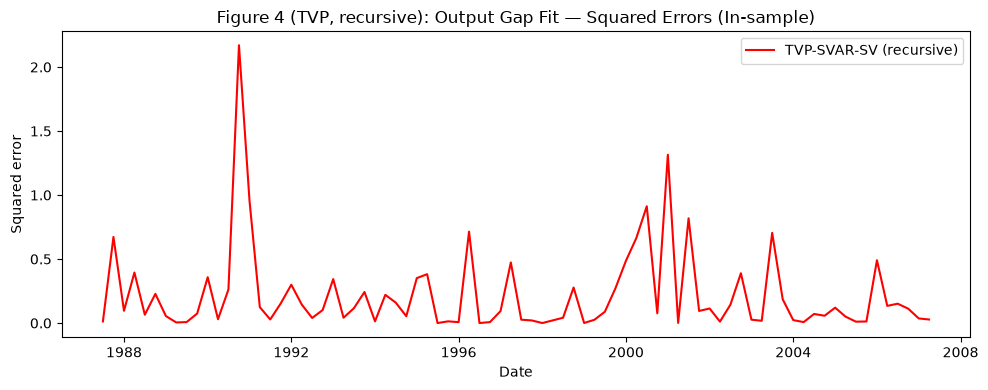

In [ ]:
plot_se(tvp_is, "se_y_tvp", title="Figure 4 (TVP, recursive): Output Gap Fit — Squared Errors (In-sample)",
        label="TVP-SVAR-SV (recursive)", name="fig4_tvp")

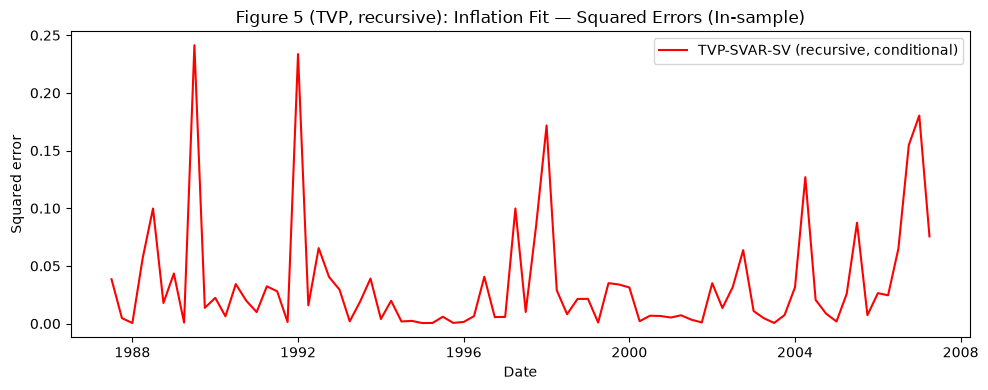

In [ ]:
plot_se(tvp_is, "se_pi_tvp", title="Figure 5 (TVP, recursive): Inflation Fit — Squared Errors (In-sample)",
        label="TVP-SVAR-SV (recursive, conditional)", name="fig5_tvp")

## Out-of-sample evaluation (2007Q3+) and uncertainty bands

We evaluate the TVP fitted paths over the out-of-sample period (2007Q3 onward) using:

- errors and squared errors:
  $$
  e_t^m = x_t^m - \hat x_t^m,\quad SE_t^m=(e_t^m)^2,\quad m\in\{y,\pi\},
  $$
- summary metrics: MSE and RMSE over the out-of-sample span.

**Credible bands:** the pointwise 5th–95th posterior percentiles of the conditional mean
$\mu_t = X_t\beta_t$ (and of its $y_t$-conditional counterpart for inflation) reflect posterior
uncertainty about the fitted conditional-mean path, not a full predictive interval that would also add
the time-varying observation noise $\sigma_{m,t}$.

In [ ]:
tvp_oos = fit_tvp.loc[OOS_START:].copy()
tvp_oos["err_y_tvp"] = tvp_oos["y"] - tvp_oos["y_hat"]
tvp_oos["err_pi_tvp"] = tvp_oos["pi"] - tvp_oos["pi_hat"]
tvp_oos["se_y_tvp"] = tvp_oos["err_y_tvp"] ** 2
tvp_oos["se_pi_tvp"] = tvp_oos["err_pi_tvp"] ** 2

mse_y_tvp = float(tvp_oos["se_y_tvp"].mean())
mse_pi_tvp = float(tvp_oos["se_pi_tvp"].mean())
print(f"TVP OOS (from {OOS_START}) | y:  MSE={mse_y_tvp:.4f}, RMSE={mse_y_tvp**0.5:.4f}, n={len(tvp_oos)}")
print(f"TVP OOS (from {OOS_START}) | pi: MSE={mse_pi_tvp:.4f}, RMSE={mse_pi_tvp**0.5:.4f}, n={len(tvp_oos)}")

TVP OOS (from 2007Q3) | y:  MSE=1.7685, RMSE=1.3298, n=76
TVP OOS (from 2007Q3) | pi: MSE=0.1953, RMSE=0.4420, n=76


## Figures (TVP, recursive): Out-of-sample tracking with posterior bands

The following figures compare realized series to the TVP posterior-mean fitted path:

- Output gap: $y_t$ vs $\hat y_t$
- Inflation: $\pi_t$ vs $\hat \pi_t$ (conditional on realized $y_t$ by construction)

Shaded regions are pointwise 90% credible bands for the conditional mean $\mu_t$.

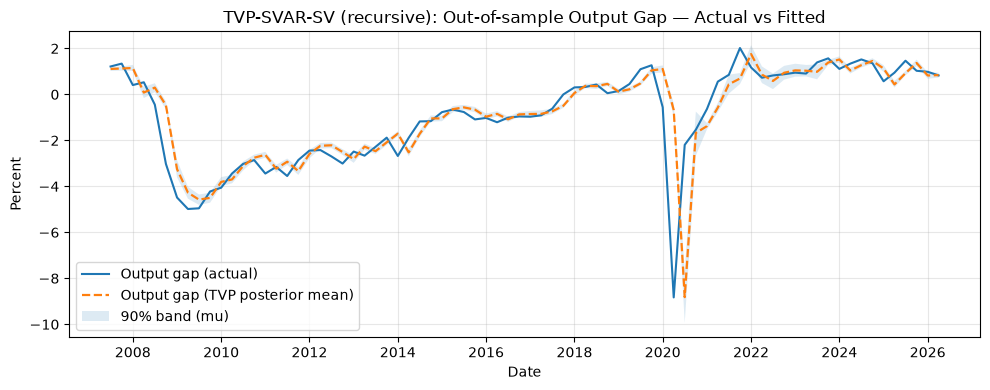

In [ ]:
plot_actual_vs_fit(tvp_oos, "y", {"Output gap (TVP posterior mean)": "y_hat"},
                   bands=("y_hat_p05", "y_hat_p95"), band_label="90% band (mu)",
                   title="TVP-SVAR-SV (recursive): Out-of-sample Output Gap — Actual vs Fitted", name="oos_tvp_y")

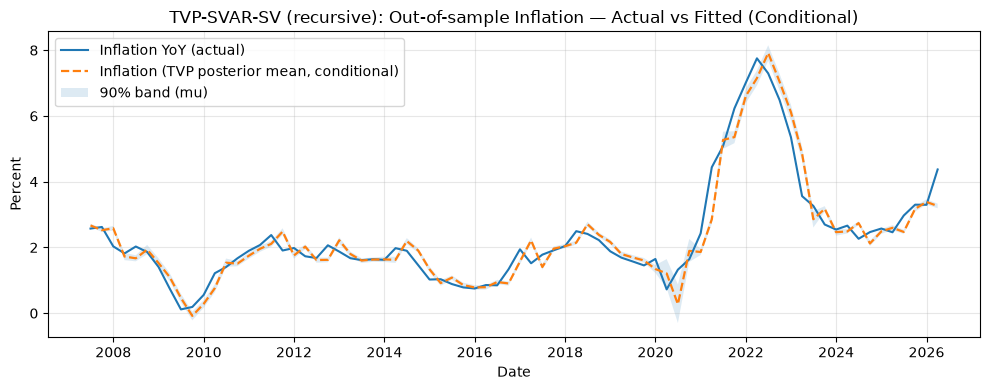

In [ ]:
plot_actual_vs_fit(tvp_oos, "pi", {"Inflation (TVP posterior mean, conditional)": "pi_hat"},
                   bands=("pi_hat_p05", "pi_hat_p95"), band_label="90% band (mu)",
                   title="TVP-SVAR-SV (recursive): Out-of-sample Inflation — Actual vs Fitted (Conditional)",
                   name="oos_tvp_pi")

## What the TVP model adds: drift and volatility

Three things a fixed-coefficient environment cannot show. First, the posterior path of individual
coefficients with 68% bands: the own-lag persistence of inflation and of the output gap, and the two
cross-equation channels a policy-learning agent cares about (the output gap's response to the lagged
policy rate and inflation's response to the lagged output gap). Second, the innovation standard deviation
of each equation over time: the Great Moderation, the crisis and 2020 are visible as volatility, not as
coefficient change. Third, the largest companion root of the posterior-mean coefficient path, which shows
whether the drifting environment passes through locally explosive dates.

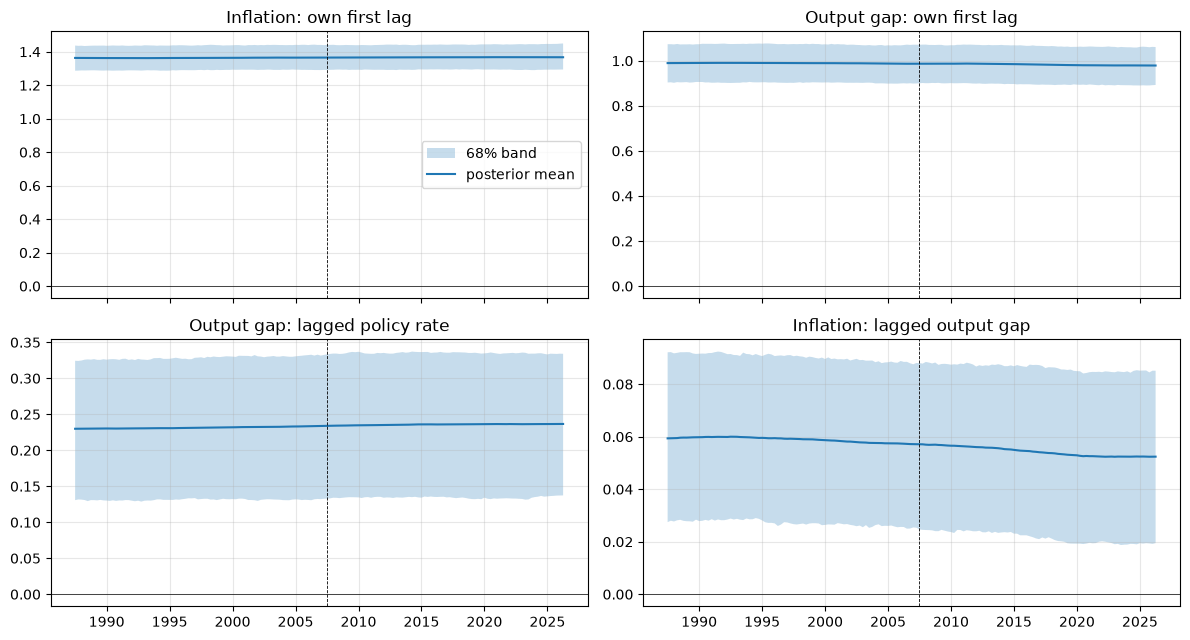

In [ ]:
dates = tvp_index.to_timestamp()
oos_line = pd.Period(OOS_START, "Q").to_timestamp()

panels = [("pi", "pi.L1", "Inflation: own first lag"), ("y", "y.L1", "Output gap: own first lag"),
          ("y", "i.L1", "Output gap: lagged policy rate"), ("pi", "y.L1", "Inflation: lagged output gap")]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharex=True)
for ax, (eq, reg, title) in zip(axes.ravel(), panels):
    low, mean, high = tvp.coefficient_path(eq, reg).T
    ax.fill_between(dates, low, high, alpha=0.25, label="68% band")
    ax.plot(dates, mean, label="posterior mean")
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(oos_line, color="k", lw=0.6, ls="--")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0, 0].legend(loc="best")
show(fig, "tvp_coefficient_paths")

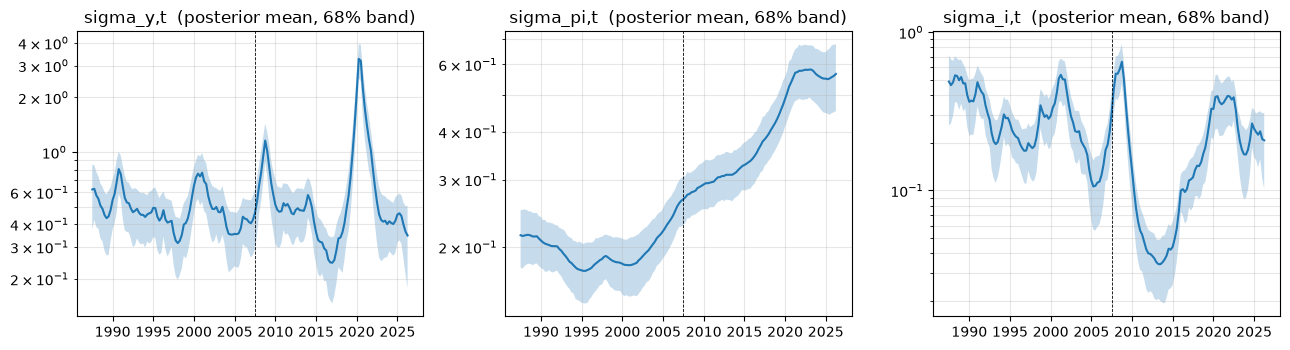

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, name in zip(axes, NAMES):
    low, mean, high = tvp.volatility_path(name).T
    ax.fill_between(dates, low, high, alpha=0.25)
    ax.plot(dates, mean)
    ax.axvline(oos_line, color="k", lw=0.6, ls="--")
    ax.set_yscale("log")
    ax.set_title(f"sigma_{name},t  (posterior mean, 68% band)")
    ax.grid(True, alpha=0.3, which="both")
show(fig, "tvp_volatility_paths")

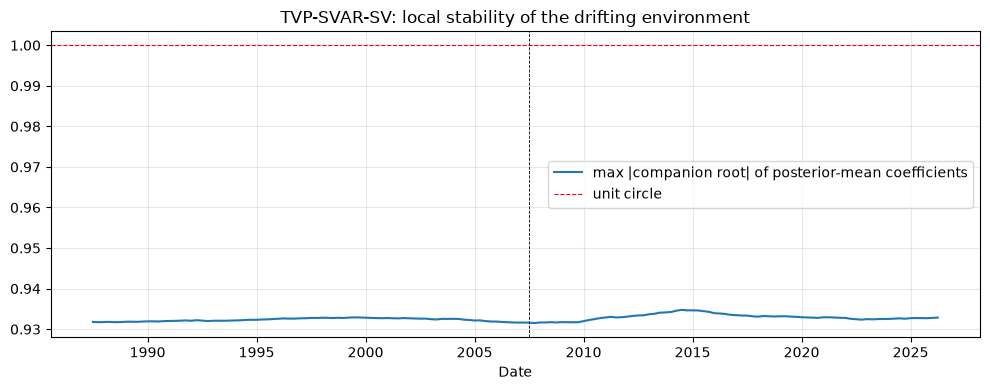

In [ ]:
fig, ax = plt.subplots()
ax.plot(dates, tvp.stability_path(), lw=1.5, label="max |companion root| of posterior-mean coefficients")
ax.axhline(1.0, color="red", lw=0.8, ls="--", label="unit circle")
ax.axvline(oos_line, color="k", lw=0.6, ls="--")
ax.set_title("TVP-SVAR-SV: local stability of the drifting environment")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend()
show(fig, "tvp_stability_path")

### Time-varying transmission of a policy-rate shock

`TimeVaryingSVAR` freezes the posterior-mean coefficients and impact matrix at a chosen date and returns
the impulse responses prevailing there. Comparing the responses of the output gap and inflation to a
one-standard-deviation policy-rate shock at three dates -- the early training sample, the trough of the
financial crisis and the post-pandemic tightening -- shows how much of the environment's transmission
mechanism the drift has moved. The responses are exact only while parameters do not drift over the
horizon, and the shock size itself varies with $\sigma_{i,t}$.

                         TVP-SVAR (TVP-VAR-SV) Results
Scheme:                      recursive  Reduced form:            TVP-VAR-SV(2)
Observations:                      156  Kept draws:                        750
--------------------------------------------------------------------------------
equation     |impact| at start   |impact| at end
y                       0.6223            0.3469
pi                      0.2147            0.5665
i                       0.4871            0.2073
The identifying restriction is recursive in the order of names, declared at
estimation time through the triangular factorization: a different ordering is a
different fitted model, not a different rotation of this one.
irf(t=...) freezes coefficients and impact at date t's posterior mean: read it
as the transmission mechanism prevailing at t, exact only while parameters do
not drift over the horizon.
Point summaries are posterior-mean plug-ins; the source result retains the draws
for full uncertainty propa

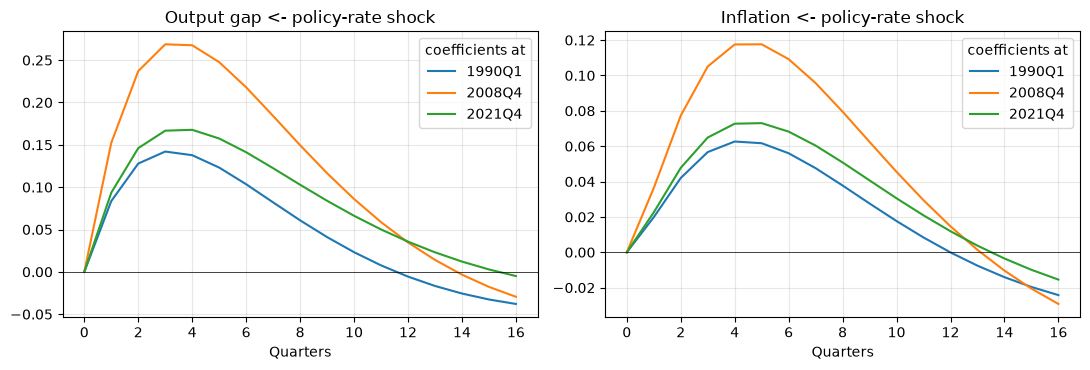

In [ ]:
tvsvar = TimeVaryingSVAR(tvp).identify()
print(tvsvar.summary())

IRF_DATES = [d for d in ("1990Q1", "2008Q4", "2021Q4") if pd.Period(d, "Q") in tvp_index]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for date in IRF_DATES:
    t = tvp_index.get_loc(pd.Period(date, "Q"))
    response = tvsvar.irf(IRF_H, t=t)                 # (horizon + 1, variable, shock)
    axes[0].plot(h, response[:, 0, 2], label=date)
    axes[1].plot(h, response[:, 1, 2], label=date)
for ax, title in zip(axes, ("Output gap <- policy-rate shock", "Inflation <- policy-rate shock")):
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(title)
    ax.set_xlabel("Quarters")
    ax.grid(True, alpha=0.3)
    ax.legend(title="coefficients at")
show(fig, "tvp_irf_policy_shock")

--------

# Summary of out-of-sample performance

One-step MSE and RMSE from 2007Q3 across the five environments. All use realized lags and inflation
conditional on realized $y_t$. The fixed, rolling and expanding rows are real-time forecasts and are
directly comparable (the model confidence set above states which of them the evaluation window can
separate); the TVP row is a smoothed (two-sided) posterior fit and is reported for completeness rather
than as a competitor.

In [ ]:
def error_metrics(frame: pd.DataFrame, y_col: str = "y_hat", pi_col: str = "pi_hat") -> dict[str, float]:
    out = {}
    for col, fit_col in (("y", y_col), ("pi", pi_col)):
        e = frame[col] - frame[fit_col]
        out[f"MSE {col}"] = float(np.mean(e**2))
        out[f"RMSE {col}"] = float(np.sqrt(np.mean(e**2)))
    out["n"] = len(frame)
    return out


summary = pd.DataFrame({
    "fixed, restricted (1987Q3-2007Q2)": error_metrics(oos_fixed),
    "fixed, unrestricted (1987Q3-2007Q2)": error_metrics(oos_fixed, "y_hat_unres", "pi_hat_unres"),
    f"rolling W={W}": error_metrics(oos_roll),
    "expanding": error_metrics(oos_expand),
    "TVP-SVAR-SV (smoothed)": error_metrics(tvp_oos),
}).T
summary["n"] = summary["n"].astype(int)
display(summary.round(4))
summary.to_csv(FIG_DIR / "oos_summary.csv")

,MSE y,RMSE y,MSE pi,RMSE pi,n
"fixed, restricted (1987Q3-2007Q2)",1.8339,1.3542,0.2941,0.5423,76
"fixed, unrestricted (1987Q3-2007Q2)",1.8062,1.3440,0.3004,0.5481,76
rolling W=40,7.8952,2.8098,0.2665,0.5162,76
expanding,2.8294,1.6821,0.2283,0.4778,76
TVP-SVAR-SV (smoothed),1.7685,1.3298,0.1953,0.4420,76


## Reading the comparison

The fixed-coefficient environment of the paper is a one-step mapping estimated once on a pre-crisis
window; its out-of-sample errors are the cost of holding that mapping fixed through the financial crisis,
the effective-lower-bound decade and the post-pandemic inflation. The re-estimation schemes ask whether
letting the mapping move helps: the expanding scheme keeps every observation and drifts slowly, the
rolling scheme forgets and adapts faster at the price of noisier coefficients, and the formal tests above
say whether the window can distinguish them at all. The TVP-SVAR-SV closes the section by showing where
the changes are: in the volatility of the shocks far more than in the coefficients that map the state
into next quarter's output gap and inflation, which is the property that makes a linear environment a
defensible benchmark for the policy-learning exercise it feeds.

--------

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., Fernández del Río, J., Wiebe, M., Peterson, P., Gérard-Marchant, P., Sheppard, K., Reddy, T., Weckesser, W., Abbasi, H., Gohlke, C., & Oliphant, T. E. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., … SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503
7. Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. In *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011
8. Kluyver, T., Ragan-Kelley, B., Pérez, F., Granger, B., Bussonnier, M., Frederic, J., Kelley, K., Hamrick, J., Grout, J., Corlay, S., Ivanov, P., Avila, D., Abdalla, S., Willing, C., & Jupyter Development Team. (2016). Jupyter Notebooks – a publishing format for reproducible computational workflows. In *Positioning and Power in Academic Publishing: Players, Agents and Agendas* (pp. 87–90). IOS Press. https://doi.org/10.3233/978-1-61499-649-1-87
9. Python Software Foundation. (2025). Python (Version 3.13) [Computer software]. https://www.python.org/

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer. https://doi.org/10.1007/3-540-27752-8
4. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press. https://doi.org/10.1017/CBO9780511599286
5. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33. https://doi.org/10.1111/j.1538-4616.2007.00014.x
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302. https://doi.org/10.1016/j.red.2004.10.009
7. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852. https://doi.org/10.1111/j.1467-937X.2005.00353.x
8. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
9. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578. https://doi.org/10.1111/j.1468-0262.2006.00718.x
10. Carter, C. K., & Kohn, R. (1994). On Gibbs sampling for state space models. *Biometrika*, 81(3), 541–553. https://doi.org/10.1093/biomet/81.3.541
11. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393. https://doi.org/10.1111/1467-937X.00050
12. Kim, C.-J., & Nelson, C. R. (1999). *State-space models with regime switching: Classical and Gibbs-sampling approaches with applications*. MIT Press.
13. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. https://doi.org/10.1080/07350015.1995.10524599
14. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. https://doi.org/10.1016/S0169-2070(96)00719-4
15. Hansen, P. R., Lunde, A., & Nason, J. M. (2011). The model confidence set. *Econometrica*, 79(2), 453–497. https://doi.org/10.3982/ECTA5771
16. Mincer, J., & Zarnowitz, V. (1969). The evaluation of economic forecasts. In J. Mincer (Ed.), *Economic forecasts and expectations: Analysis of forecasting behavior and performance* (pp. 3–46). NBER.
17. Waggoner, D. F., & Zha, T. (1999). Conditional forecasts in dynamic multivariate models. *Review of Economics and Statistics*, 81(4), 639–651. https://doi.org/10.1162/003465399558508
18. Federal Reserve Bank of St. Louis. (n.d.). *Federal Reserve Economic Data (FRED)*. https://fred.stlouisfed.org/